In [1]:
import pandas as pd
import numpy as np
import os

# --- 경로 설정 ---
VENDOR_ANALYSIS_PATH = "../output/problem2_vendor/problem2_vendor_analysis_base.csv"
GICS_PATH = "../output/gics_clean.csv" 
OUT_DIR = "../output/problem3_sensitivity" 
os.makedirs(OUT_DIR, exist_ok=True)

# GICS 분류 레벨과 분석할 수익률 기간
GICS_LEVELS = ['sector', 'industry_group', 'industry', 'sub_industry']
RETURN_COLUMNS = ['return_post_1d', 'return_post_2d', 'return_post_5d', 'return_post_10d', 'return_post_20d']

# 데이터 분할 기준 (2020-2023: 훈련/규칙 도출)
VALIDATION_START_DATE = pd.to_datetime('2024-01-01')

# --- 1. 데이터 로드 및 훈련 데이터 분할 ---
print("➡️ 1. 데이터 로드 및 훈련 데이터(2020-2023) 분할 시작...")

try:
    # 필요한 모든 수익률 컬럼을 usecols에 포함
    all_usecols = ['symbol', 'date', 'surprise_z'] + RETURN_COLUMNS
    df_full = pd.read_csv(
        VENDOR_ANALYSIS_PATH, 
        usecols=all_usecols,
        dtype={col: np.float64 for col in all_usecols if col not in ['symbol', 'date']}
    ).dropna(subset=['surprise_z'] + RETURN_COLUMNS) # 모든 수익률 컬럼이 있는 행만 사용
    
    df_full['date'] = pd.to_datetime(df_full['date'])
    df_train = df_full[df_full['date'] < VALIDATION_START_DATE].copy()
    
    # GICS 산업 분류 데이터 로드 및 타입 수정
    df_gics = pd.read_csv(GICS_PATH, dtype={c: np.float64 for c in GICS_LEVELS})
    
    if df_train.empty:
         raise ValueError("훈련 데이터셋(2020-2023)이 비어있습니다. 분석을 진행할 수 없습니다.")

except FileNotFoundError as e:
    print(f"❌ 오류: 필요한 파일을 찾을 수 없습니다. 경로를 확인하세요: {e}")
    exit()
except Exception as e:
    print(f"❌ 오류: 데이터 처리 중 예상치 못한 오류 발생: {e}")
    exit()


# --- 2. 훈련 단계: 모든 GICS 레벨별 장기 수익률 분석 ---

# A. Z-Score 임계값 확정 (훈련 데이터의 분포 기준)
TRAIN_MEAN_Z = df_train['surprise_z'].mean() 
TRAIN_STD_Z = df_train['surprise_z'].std() 
Z_SCORE_THRESHOLD = 2.0 

# B. Positive Signal 필터링 및 병합
df_train['is_positive_signal'] = df_train['surprise_z'] > TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z
df_positive_train = df_train[df_train['is_positive_signal']].copy()

if df_positive_train.empty:
    print("분석: 훈련 기간 동안 Positive Signal이 발생하지 않아 분석을 건너뜁니다.")
    exit()
    
df_merged_train = pd.merge(df_positive_train, df_gics, on='symbol', how='left')
df_merged_train = df_merged_train.dropna(subset=GICS_LEVELS + ['return_post_1d']) # 분석에 필수적인 행 제거


print(f"➡️ 2. 모든 GICS 레벨에 대한 장기 민감도 분석 시작...")

# 최종 결과를 담을 딕셔너리
all_levels_results = {}

for level in GICS_LEVELS:
    # GICS 레벨별 평균 수익률 계산
    df_sensitivity = df_merged_train.groupby(level)[RETURN_COLUMNS].mean()
    df_sensitivity = df_sensitivity.mul(100).round(3) # 백분율 변환
    
    # 컬럼 이름 변경
    column_rename_map = {
        col: f"Avg_Return_Post_{col.split('_')[-1].replace('d', 'D')} (%)" 
        for col in RETURN_COLUMNS
    }
    df_sensitivity = df_sensitivity.rename(columns=column_rename_map)
    
    # Post 1D 수익률 기준으로 정렬
    df_sensitivity_sorted = df_sensitivity.sort_values(by='Avg_Return_Post_1D (%)', ascending=False)
    
    all_levels_results[level] = df_sensitivity_sorted


# --- 3. 최종 결과 출력 및 최적 레벨 확정 ---

print("\n" + "="*90)
print("🏆 과제 3: 모든 GICS 레벨별 Positive Signal 장기 민감도 분석 (2020-2023 훈련)")
print("="*90)

# 모든 레벨의 결과를 출력
for level, df_result in all_levels_results.items():
    print(f"\n--- GICS Level: {level.upper()} ---")
    
    # 1D 수익률이 가장 높은 코드 확정
    best_code = df_result.index[0]
    best_return = df_result.iloc[0]['Avg_Return_Post_1D (%)']
    
    print(f"  > 최적 코드 ({level}): {best_code} (1D 평균 {best_return:.3f}%)")
    print(df_result.to_markdown())

print("="*90)

➡️ 1. 데이터 로드 및 훈련 데이터(2020-2023) 분할 시작...
➡️ 2. 모든 GICS 레벨에 대한 장기 민감도 분석 시작...

🏆 과제 3: 모든 GICS 레벨별 Positive Signal 장기 민감도 분석 (2020-2023 훈련)

--- GICS Level: SECTOR ---
  > 최적 코드 (sector): 35.0 (1D 평균 0.535%)
|   sector |   Avg_Return_Post_1D (%) |   Avg_Return_Post_2D (%) |   Avg_Return_Post_5D (%) |   Avg_Return_Post_10D (%) |   Avg_Return_Post_20D (%) |
|---------:|-------------------------:|-------------------------:|-------------------------:|--------------------------:|--------------------------:|
|       35 |                    0.535 |                    1.133 |                    2.415 |                     0.73  |                     0.156 |
|       20 |                    0.533 |                    1.337 |                    2.079 |                     2.45  |                     4.327 |
|       30 |                    0.428 |                    1.811 |                    2.311 |                     3.289 |                     3.682 |
|       15 |                    0.366 |  

In [3]:
import pandas as pd
import numpy as np
import os

# --- 경로 설정 ---
VENDOR_ANALYSIS_PATH = "../output/problem2_vendor/problem2_vendor_analysis_base.csv"
GICS_PATH = "../output/gics_clean.csv" 
OUT_DIR = "../output/problem3_sensitivity" 
os.makedirs(OUT_DIR, exist_ok=True)

# 규칙 설정 (훈련 데이터 분석 결과 반영)
TARGET_GICS_LEVEL = 'industry_group' # 최적화 레벨 (Sector 대신 Industry Group 사용)
TARGET_GICS_CODE = 2550.0 # 최적 GICS 코드 (훈련 결과: 7.036% 수익)
Z_SCORE_THRESHOLD = 2.0 

RETURN_COLUMNS_ALL = ['return_post_1d', 'return_post_2d', 'return_post_5d', 'return_post_10d', 'return_post_20d']
VALIDATION_START_DATE = pd.to_datetime('2024-01-01')

# --- 1. 데이터 로드 및 훈련/검증 분할 ---
print("➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...")

try:
    df_full = pd.read_csv(
        VENDOR_ANALYSIS_PATH, 
        usecols=['symbol', 'date', 'surprise_z'] + RETURN_COLUMNS_ALL,
        dtype={col: np.float64 for col in ['surprise_z'] + RETURN_COLUMNS_ALL}
    ).dropna(subset=['surprise_z'] + RETURN_COLUMNS_ALL)
    
    df_full['date'] = pd.to_datetime(df_full['date'])
    df_gics = pd.read_csv(GICS_PATH)
    df_gics[TARGET_GICS_LEVEL] = df_gics[TARGET_GICS_LEVEL].astype(np.float64) 
    
    # 데이터 분할
    df_train = df_full[df_full['date'] < VALIDATION_START_DATE].copy()
    df_validation = df_full[df_full['date'] >= VALIDATION_START_DATE].copy()
    
except FileNotFoundError as e:
    print(f"❌ 오류: 필요한 파일을 찾을 수 없습니다. 경로를 확인하세요: {e}")
    exit()
except Exception as e:
    print(f"❌ 오류: 데이터 처리 중 예상치 못한 오류 발생: {e}")
    exit()


# --- 2. 규칙 도출 (훈련 데이터 2020-2023 기반) ---
TRAIN_MEAN_Z = df_train['surprise_z'].mean() 
TRAIN_STD_Z = df_train['surprise_z'].std() 

# GICS 정보 병합
df_validation = pd.merge(df_validation, df_gics[['symbol', TARGET_GICS_LEVEL]], on='symbol', how='left')
df_validation = df_validation.dropna(subset=[TARGET_GICS_LEVEL] + ['return_post_1d'])


# --- 3. 검증 단계: 규칙 평가 (2024년 데이터 적용) ---

# A. 최종 규칙 기반 모델 적용 함수
def apply_final_rule_validation(row):
    # 1. GICS 필터링 (최적 Industry Group 2550.0 반영)
    if row[TARGET_GICS_LEVEL] != TARGET_GICS_CODE:
        return 'HOLD'
    
    # 2. Z-Score 임계값 필터링 (BUY Only)
    if row['surprise_z'] > TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z:
        return 'BUY'
    else:
        return 'HOLD'

df_validation['decision'] = df_validation.apply(apply_final_rule_validation, axis=1)

# B. BUY 시그널 발생 행만 필터링 (Long-Only)
df_signals_validation = df_validation[df_validation['decision'] == 'BUY'].copy()

if df_signals_validation.empty:
    print("분석: 검증 데이터에서 BUY 시그널이 전혀 발생하지 않았습니다.")
    exit()


# C. 성능 측정 (Avg Return)
print("➡️ 2. 최종 BUY Only 전략의 장기 수익률 계산 시작...")

# 수익률 컬럼에 포지션 수익 반영 (Long-Only 이므로 그대로 사용)
df_avg_return_val = df_signals_validation[RETURN_COLUMNS_ALL].mean()

# Precision 계산 (Post 1D 기준)
precision_1d = (df_signals_validation['return_post_1d'] > 0).mean() * 100


# D. 최종 결과 출력
column_rename_map = {
    col: f"Avg_Return_{col.replace('return_post_', 'Post_').replace('d', 'D')} (%)" 
    for col in RETURN_COLUMNS_ALL
}
df_avg_return_val = df_avg_return_val.mul(100).round(4).rename(column_rename_map)


# --- 4. 최종 검증 결과 출력 ---
print("\n" + "="*80)
print("🏆 최종 모델 검증 결과 (GICS Industry Group 2550.0 Long-Only)")
print("="*80)
print(f"평가 기간: 2024년 | 총 BUY 시그널 수: {len(df_signals_validation)}개")
print(f"적용 규칙: {TARGET_GICS_LEVEL.upper()} {TARGET_GICS_CODE} & Z > +{Z_SCORE_THRESHOLD} (Long Only)")

print(f"\n1. 단기 정밀도 (Post 1D Precision): {precision_1d:.2f}%")

print("\n2. 장기 평균 수익률 (Avg Return)")
print(df_avg_return_val.to_markdown())
print("="*80)

➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...
➡️ 2. 최종 BUY Only 전략의 장기 수익률 계산 시작...

🏆 최종 모델 검증 결과 (GICS Industry Group 2550.0 Long-Only)
평가 기간: 2024년 | 총 BUY 시그널 수: 1개
적용 규칙: INDUSTRY_GROUP 2550.0 & Z > +2.0 (Long Only)

1. 단기 정밀도 (Post 1D Precision): 0.00%

2. 장기 평균 수익률 (Avg Return)
|                         |        0 |
|:------------------------|---------:|
| Avg_Return_Post_1D (%)  |  -8.6614 |
| Avg_Return_Post_2D (%)  |  -9.0551 |
| Avg_Return_Post_5D (%)  |  -6.4961 |
| Avg_Return_Post_10D (%) | -16.9291 |
| Avg_Return_Post_20D (%) | -25.8268 |


- 더 세부적인 분류로 갈수록 과적합으로 이어짐

In [7]:
import pandas as pd
import numpy as np
import os

# --- 경로 설정 및 상수 ---
VENDOR_ANALYSIS_PATH = "../output/problem2_vendor/problem2_vendor_analysis_base.csv"
GICS_PATH = "../output/gics_clean.csv" 
OUT_DIR = "../output/problem3_sensitivity" 
os.makedirs(OUT_DIR, exist_ok=True)

TARGET_GICS_LEVEL = 'sector'
Z_SCORE_THRESHOLD = 2.0
# 분석할 모든 장기 수익률 컬럼
RETURN_COLUMNS_ALL = ['return_post_1d', 'return_post_2d', 'return_post_5d', 'return_post_10d', 'return_post_20d']
VALIDATION_START_DATE = pd.to_datetime('2024-01-01')

# --- 1. 데이터 로드 및 훈련/검증 분할 ---
print("➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...")

try:
    # A. 분석 데이터 로드 (Full)
    df_full = pd.read_csv(
        VENDOR_ANALYSIS_PATH, 
        usecols=['symbol', 'date', 'surprise_z'] + RETURN_COLUMNS_ALL,
        dtype={col: np.float64 for col in ['surprise_z'] + RETURN_COLUMNS_ALL}
    ).dropna(subset=['surprise_z'] + RETURN_COLUMNS_ALL)
    df_full['date'] = pd.to_datetime(df_full['date'])
    
    # B. GICS 정보 로드
    df_gics = pd.read_csv(GICS_PATH)
    df_gics[TARGET_GICS_LEVEL] = df_gics[TARGET_GICS_LEVEL].astype(np.float64) 
    
    # 데이터 분할
    df_train = df_full[df_full['date'] < VALIDATION_START_DATE].copy()
    df_validation = df_full[df_full['date'] >= VALIDATION_START_DATE].copy()
    
except Exception as e:
    print(f"❌ 오류: 데이터 로드 중 오류 발생: {e}")
    exit()

# --- 2. 규칙 도출 (훈련 데이터 2020-2023 기반) ---
TRAIN_MEAN_Z = df_train['surprise_z'].mean() 
TRAIN_STD_Z = df_train['surprise_z'].std() 

# GICS 정보 병합
df_validation = pd.merge(df_validation, df_gics[['symbol', TARGET_GICS_LEVEL]], on='symbol', how='left')
df_validation = df_validation.dropna(subset=[TARGET_GICS_LEVEL] + ['return_post_1d'])


# --- 3. 모든 섹터 규칙 검증 함수 (BUY/SELL 포함) ---

def calculate_all_sector_validation(df_val: pd.DataFrame) -> pd.DataFrame:
    
    unique_sectors = df_val[TARGET_GICS_LEVEL].unique()
    all_results = []

    # BUY/SELL 시그널 분류 (훈련 데이터 통계치 사용)
    is_positive_signal = df_val['surprise_z'] > TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z
    is_negative_signal = df_val['surprise_z'] < TRAIN_MEAN_Z - Z_SCORE_THRESHOLD * TRAIN_STD_Z

    df_signals = df_val[is_positive_signal | is_negative_signal].copy()

    for sector_code in unique_sectors:
        df_sector = df_signals[df_signals[TARGET_GICS_LEVEL] == sector_code].copy()

        if df_sector.empty:
            continue
            
        # 1. BUY 성능
        df_buy = df_sector[df_sector['surprise_z'] > TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z].copy()
        if not df_buy.empty:
            result = {'sector': sector_code, 'Decision': 'BUY (Long)', 'Total_Signals': len(df_buy)}
            
            for col in RETURN_COLUMNS_ALL:
                # 수익률 계산 (Long)
                result[f'Avg_Return_{col}'] = df_buy[col].mean()
                
            all_results.append(result)

        # 2. SELL 성능
        df_sell = df_sector[df_sector['surprise_z'] < TRAIN_MEAN_Z - Z_SCORE_THRESHOLD * TRAIN_STD_Z].copy()
        if not df_sell.empty:
            result = {'sector': sector_code, 'Decision': 'SELL (Short)', 'Total_Signals': len(df_sell)}
            
            for col in RETURN_COLUMNS_ALL:
                # 수익률 계산 (Short: 부호 반전하여 수익으로 간주)
                result[f'Avg_Return_{col}'] = (-df_sell[col]).mean()
            
            all_results.append(result)

    if not all_results:
        return pd.DataFrame()
        
    df_results = pd.DataFrame(all_results)
    
    # 5. 컬럼 이름 정리 및 출력 형태 변환
    column_rename_map = {}
    for col in RETURN_COLUMNS_ALL:
        df_results[f'Avg_Return_Post_{col.split("_")[-1].replace("d", "D")} (%)'] = df_results.pop(f'Avg_Return_{col}') * 100
    
    return df_results.sort_values(by=['sector', 'Decision'])


# --- 4. 최종 실행 및 출력 ---
print("➡️ 2. 모든 GICS Sector에 대한 BUY/SELL 전략 검증 시작...")
df_validation_results = calculate_all_sector_validation(df_validation)


if df_validation_results.empty:
    print("분석: 검증 데이터에서 유효한 BUY/SELL 시그널이 발생한 GICS Sector가 없습니다.")
    exit()


print("\n" + "="*90)
print(f"🏆 모든 GICS Sector BUY/SELL 전략 검증 결과 (2024년 평가)")
print("="*90)

# 최종 결과 테이블 출력
print("1. 장기 수익률 검증 테이블 (Post 1D ~ 20D)")
print(df_validation_results.to_markdown(index=False))
print("\n" + "="*90)

# 최종 결론을 위한 최적 Sector (Post 20D 수익률 기준)
df_buy_performance = df_validation_results[df_validation_results['Decision'] == 'BUY (Long)'].sort_values(by='Avg_Return_Post_20D (%)', ascending=False)
best_sector_code_20d = df_buy_performance.iloc[0]['sector']
best_20d_return = df_buy_performance.iloc[0]['Avg_Return_Post_20D (%)']

print(f"✅ 2024년 검증 기간 중 최고의 장기 BUY 수익률 (20D)을 보인 Sector: {best_sector_code_20d} (Avg Return: {best_20d_return:.4f}%)")
print("="*90)

➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...
➡️ 2. 모든 GICS Sector에 대한 BUY/SELL 전략 검증 시작...

🏆 모든 GICS Sector BUY/SELL 전략 검증 결과 (2024년 평가)
1. 장기 수익률 검증 테이블 (Post 1D ~ 20D)
|   sector | Decision     |   Total_Signals |   Avg_Return_Post_1D (%) |   Avg_Return_Post_2D (%) |   Avg_Return_Post_5D (%) |   Avg_Return_Post_10D (%) |   Avg_Return_Post_20D (%) |
|---------:|:-------------|----------------:|-------------------------:|-------------------------:|-------------------------:|--------------------------:|--------------------------:|
|       10 | SELL (Short) |               1 |                 3.28305  |                 2.75067  |                 1.1535   |                  4.43656  |                 11.2689   |
|       15 | BUY (Long)   |               4 |                 0.461115 |                 0.597435 |                -0.4274   |                  0.952732 |                 -2.06784  |
|       15 | SELL (Short) |               6 |                -1.57751  |                -1.91516  |             

In [11]:
import pandas as pd
import numpy as np
import os

# --- 경로 설정 및 상수 ---
VENDOR_ANALYSIS_PATH = "../output/problem2_vendor/problem2_vendor_analysis_base.csv"
GICS_PATH = "../output/gics_clean.csv" 
OUT_DIR = "../output/problem3_sensitivity" 
os.makedirs(OUT_DIR, exist_ok=True)

# 규칙 설정
TARGET_GICS_LEVEL = 'sector'
Z_SCORE_THRESHOLD = 2.0
RETURN_COLUMNS = ['return_post_1d', 'return_post_2d'] # 검증에 필요한 최소 수익률 컬럼
RETURN_COLUMNS_ALL = ['return_post_1d', 'return_post_2d', 'return_post_5d', 'return_post_10d', 'return_post_20d']
VALIDATION_START_DATE = pd.to_datetime('2024-01-01')


# --- 1. 데이터 로드 및 훈련/검증 분할 ---
print("➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...")

try:
    # A. 분석 데이터 로드 (모든 장기 수익률 컬럼 포함)
    df_full = pd.read_csv(
        VENDOR_ANALYSIS_PATH, 
        usecols=['symbol', 'date', 'surprise_z'] + RETURN_COLUMNS_ALL,
        dtype={col: np.float64 for col in ['surprise_z'] + RETURN_COLUMNS_ALL}
    ).dropna(subset=['surprise_z'] + RETURN_COLUMNS_ALL)
    df_full['date'] = pd.to_datetime(df_full['date'])
    
    # B. GICS 정보 로드
    df_gics = pd.read_csv(GICS_PATH)
    df_gics[TARGET_GICS_LEVEL] = df_gics[TARGET_GICS_LEVEL].astype(np.float64) 
    
    # 데이터 분할
    df_train = df_full[df_full['date'] < VALIDATION_START_DATE].copy()
    df_validation = df_full[df_full['date'] >= VALIDATION_START_DATE].copy()
    
except Exception as e:
    print(f"❌ 오류: 데이터 로드 중 오류 발생: {e}")
    exit()

# --- 2. 규칙 도출 (훈련 데이터 2020-2023 기반) ---
TRAIN_MEAN_Z = df_train['surprise_z'].mean() 
TRAIN_STD_Z = df_train['surprise_z'].std() 

# GICS 정보 병합
df_validation = pd.merge(df_validation, df_gics[['symbol', TARGET_GICS_LEVEL]], on='symbol', how='left')
df_validation = df_validation.dropna(subset=[TARGET_GICS_LEVEL] + ['return_post_1d'])


# --- 3. 모든 섹터 규칙 검증 함수 (BUY/SELL 포함) ---

def calculate_all_sector_validation(df_val: pd.DataFrame) -> pd.DataFrame:
    
    unique_sectors = df_val[TARGET_GICS_LEVEL].unique()
    all_results = []

    # BUY/SELL 시그널 분류 (훈련 데이터 통계치 사용)
    is_positive_signal = df_val['surprise_z'] > TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z
    is_negative_signal = df_val['surprise_z'] < TRAIN_MEAN_Z - Z_SCORE_THRESHOLD * TRAIN_STD_Z

    df_signals = df_val[is_positive_signal | is_negative_signal].copy()

    for sector_code in unique_sectors:
        df_sector = df_signals[df_signals[TARGET_GICS_LEVEL] == sector_code].copy()

        if df_sector.empty:
            continue
            
        # 1. BUY 성능
        df_buy = df_sector[df_sector['surprise_z'] > TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z].copy()
        if not df_buy.empty:
            
            # Precision 계산
            buy_precision = (df_buy['return_post_1d'] > 0).mean() * 100
            
            result = {'sector': sector_code, 'Decision': 'BUY (Long)', 'Total_Signals': len(df_buy), 'Precision (%)': round(buy_precision, 2)}
            
            # 장기 수익률 계산
            for col in RETURN_COLUMNS_ALL:
                result[f"Avg_Return_Post_{col.split('_')[-1].replace('d', 'D')} (%)"] = df_buy[col].mean() * 100
            
            all_results.append(result)

        # 2. SELL 성능
        df_sell = df_sector[df_sector['surprise_z'] < TRAIN_MEAN_Z - Z_SCORE_THRESHOLD * TRAIN_STD_Z].copy()
        if not df_sell.empty:
            
            # Precision 계산
            sell_precision = (df_sell['return_post_1d'] < 0).mean() * 100
            
            result = {'sector': sector_code, 'Decision': 'SELL (Short)', 'Total_Signals': len(df_sell), 'Precision (%)': round(sell_precision, 2)}
            
            # 장기 수익률 계산 (Short: 부호 반전하여 수익으로 간주)
            for col in RETURN_COLUMNS_ALL:
                result[f"Avg_Return_Post_{col.split('_')[-1].replace('d', 'D')} (%)"] = (-df_sell[col]).mean() * 100
            
            all_results.append(result)

    df_results = pd.DataFrame(all_results)
    return df_results.sort_values(by=['sector', 'Decision'])


# --- 4. 최종 실행 및 출력 ---
print("➡️ 2. 모든 GICS Sector에 대한 BUY/SELL 전략 검증 시작...")
df_validation_results = calculate_all_sector_validation(df_validation)


if df_validation_results.empty:
    print("분석: 검증 데이터에서 유효한 BUY/SELL 시그널이 발생한 GICS Sector가 없습니다.")
    exit()


print("\n" + "="*120)
print(f"🏆 모든 GICS Sector BUY/SELL 전략 검증 결과 (2024년 평가)")
print("="*120)

# 최종 결과 테이블 출력
print("1. 장기 수익률 및 정밀도 검증 테이블")
print(df_validation_results.to_markdown(index=False))
print("\n" + "="*120)

# 최종 결론을 위한 최적 Sector (Post 20D 수익률 기준)
df_buy_performance = df_validation_results[df_validation_results['Decision'] == 'BUY (Long)'].sort_values(by='Avg_Return_Post_20D (%)', ascending=False)
best_sector_code_20d = df_buy_performance.iloc[0]['sector']
best_20d_return = df_buy_performance.iloc[0]['Avg_Return_Post_20D (%)']

print(f"✅ 2024년 검증 기간 중 최고의 장기 BUY 수익률 (20D)을 보인 Sector: {best_sector_code_20d} (Avg Return: {best_20d_return:.4f}%)")
print("="*120)

➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...
➡️ 2. 모든 GICS Sector에 대한 BUY/SELL 전략 검증 시작...

🏆 모든 GICS Sector BUY/SELL 전략 검증 결과 (2024년 평가)
1. 장기 수익률 및 정밀도 검증 테이블
|   sector | Decision     |   Total_Signals |   Precision (%) |   Avg_Return_Post_1D (%) |   Avg_Return_Post_2D (%) |   Avg_Return_Post_5D (%) |   Avg_Return_Post_10D (%) |   Avg_Return_Post_20D (%) |
|---------:|:-------------|----------------:|----------------:|-------------------------:|-------------------------:|-------------------------:|--------------------------:|--------------------------:|
|       10 | SELL (Short) |               1 |          100    |                 3.28305  |                 2.75067  |                 1.1535   |                  4.43656  |                 11.2689   |
|       15 | BUY (Long)   |               4 |           50    |                 0.461115 |                 0.597435 |                -0.4274   |                  0.952732 |                 -2.06784  |
|       15 | SELL (Short) |               6 |     

➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...

➡️ 2. 8개 Sector별 시각화 생성 시작...
⚠️ Sector 10.0: BUY 시그널이 없어 그래프 생략.


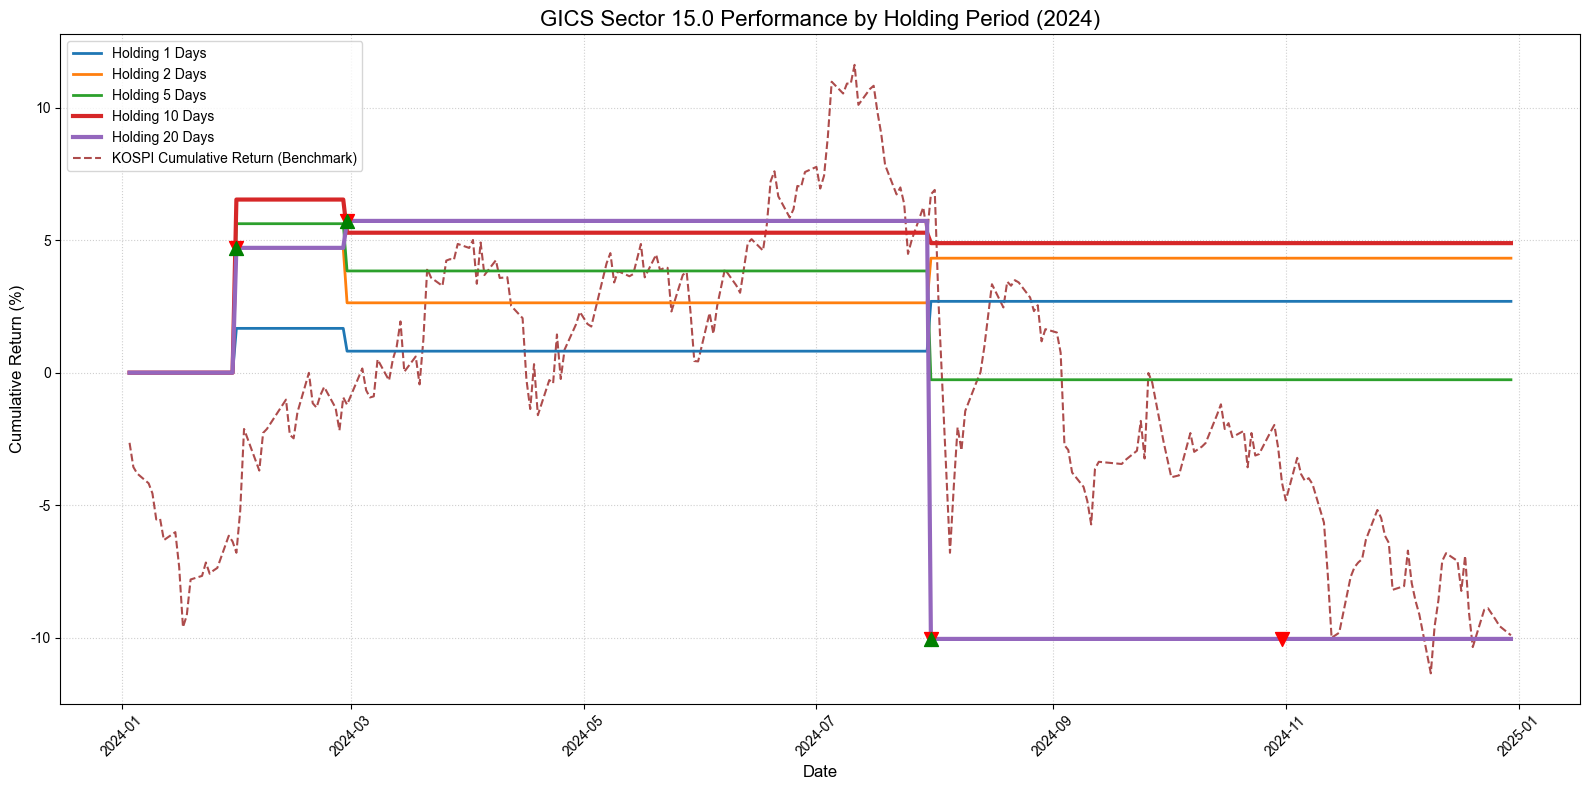

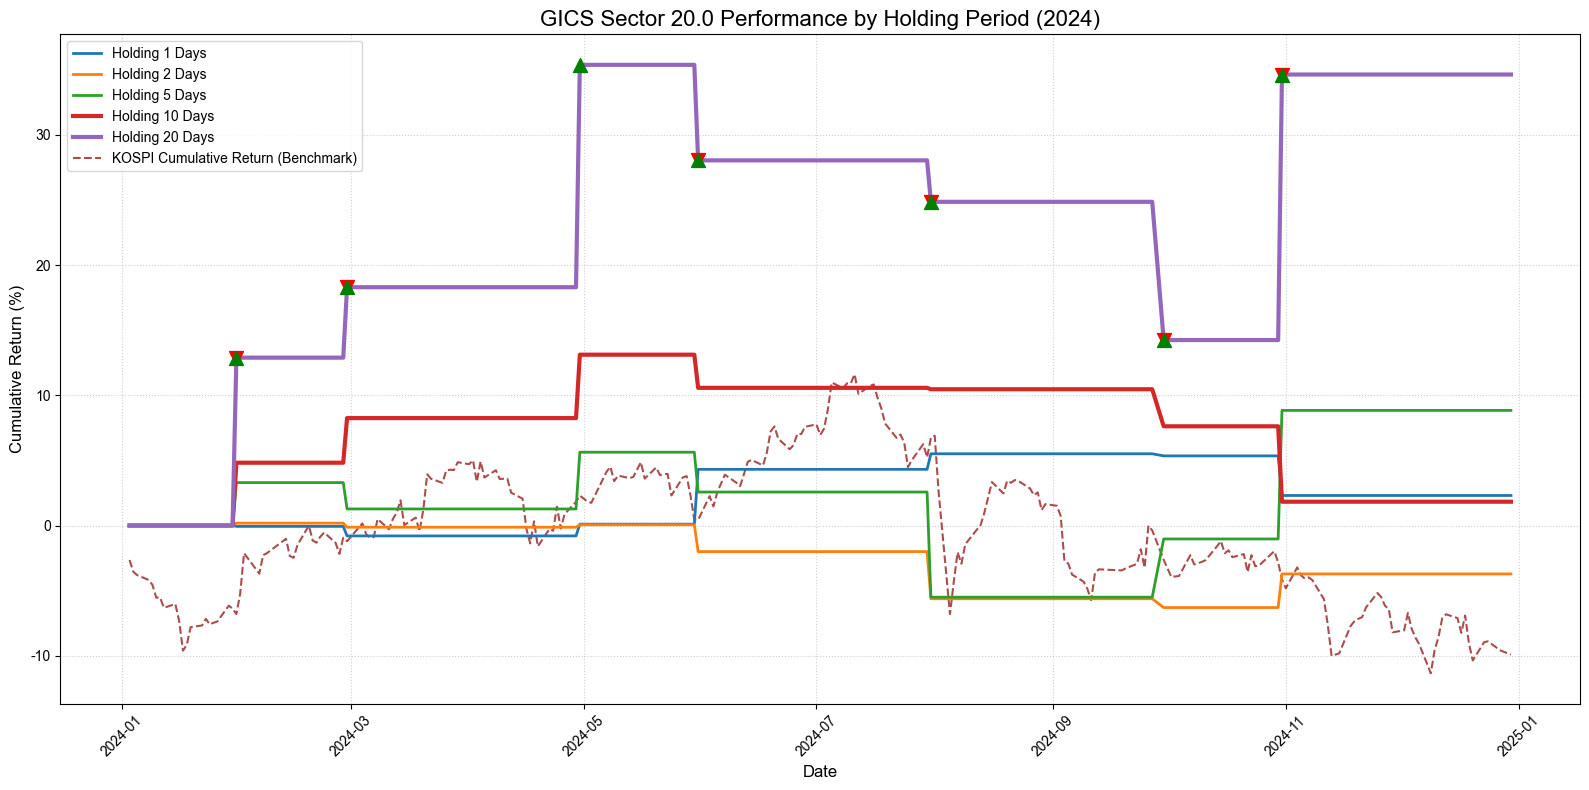

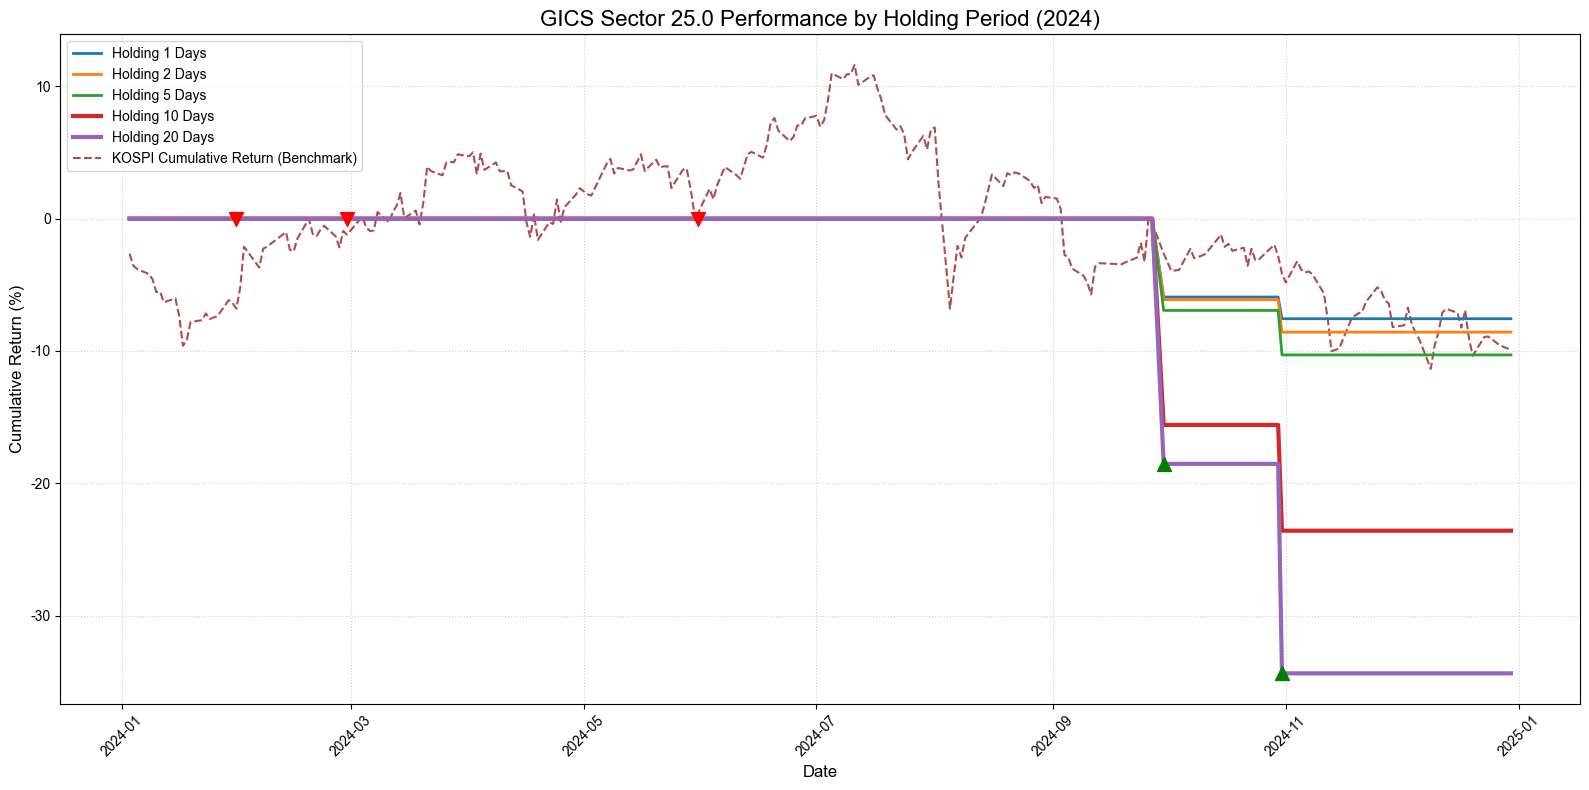

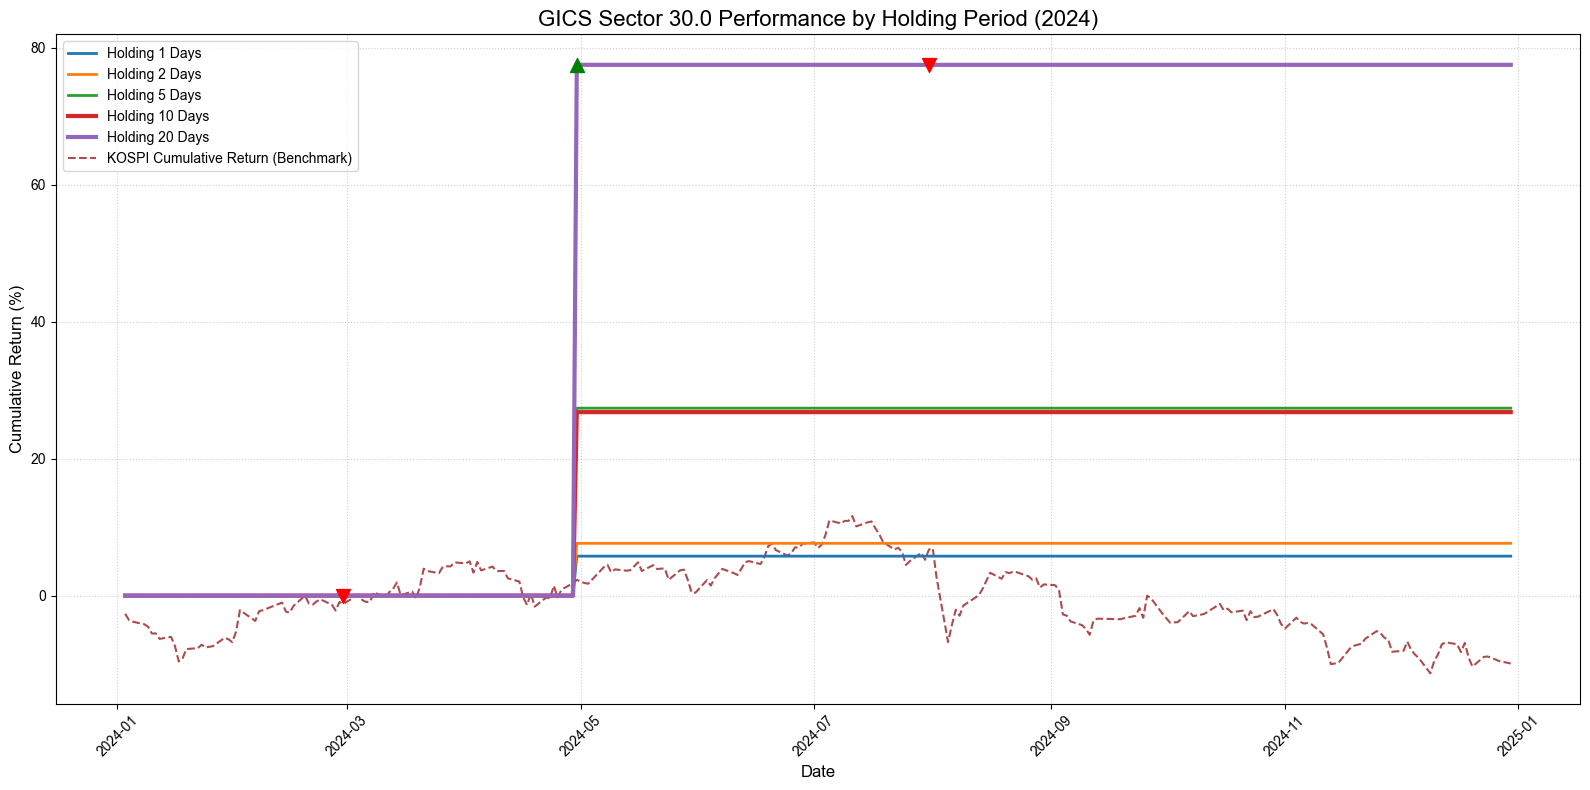

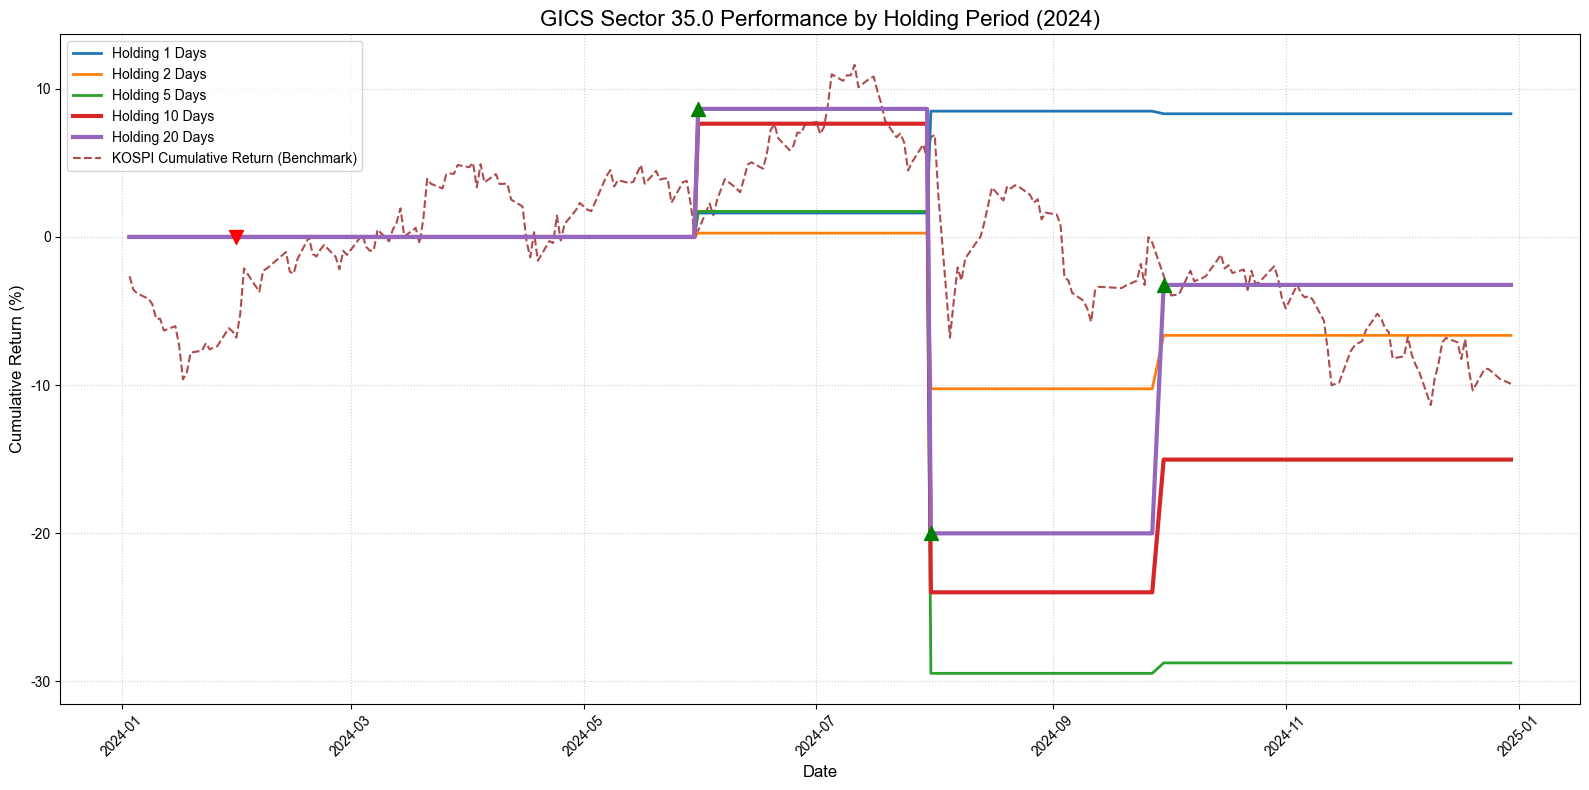

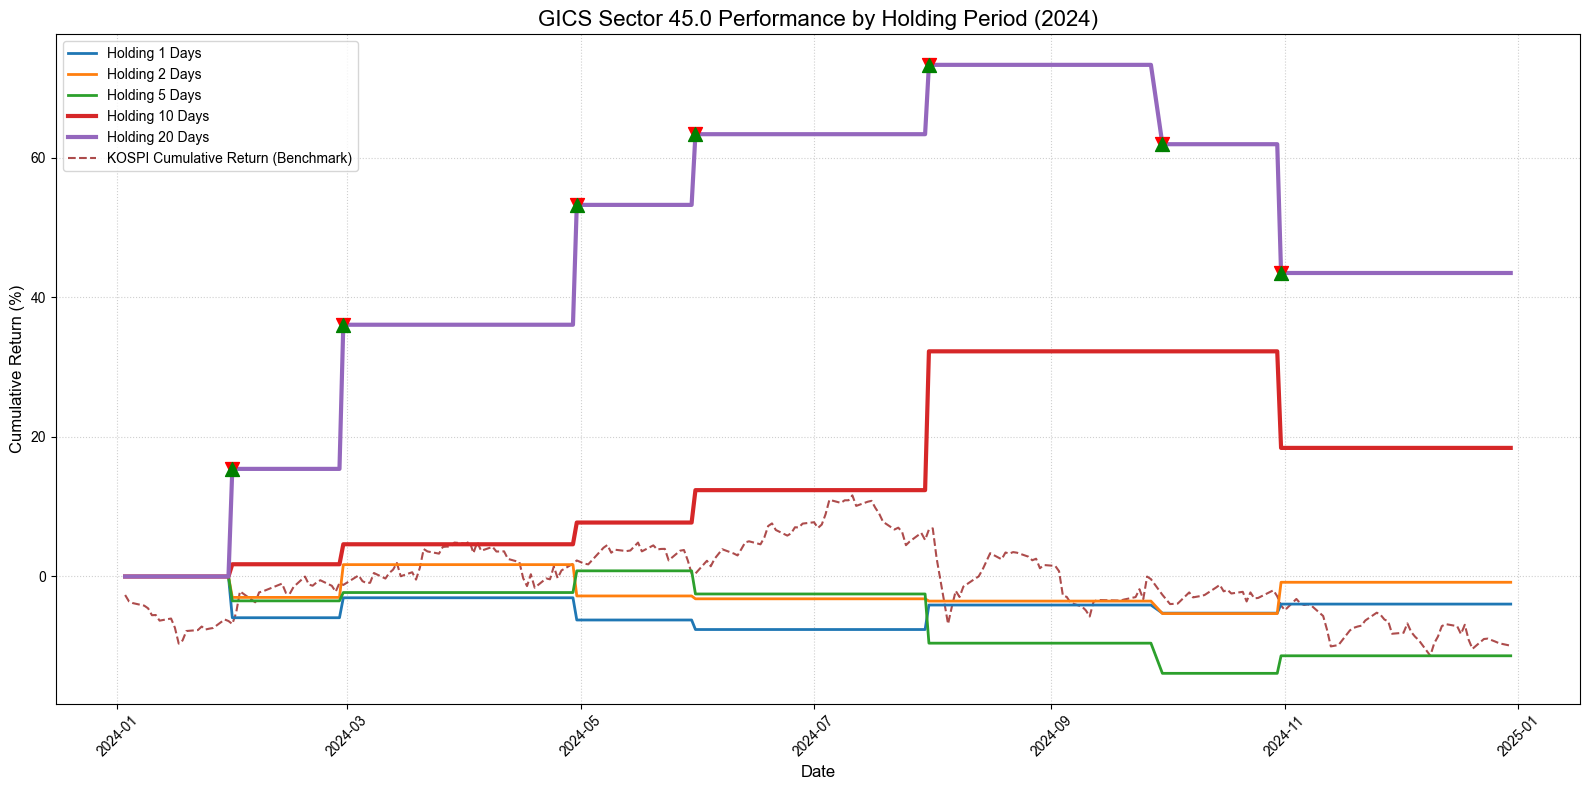

⚠️ Sector 50.0: BUY 시그널이 없어 그래프 생략.

✅ 8개 Sector별 시각화 완료. 저장 폴더: ../output/problem4_retention_analysis_all_sectors


In [18]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import rc

# --- 1. 설정 및 데이터 로드 ---
VENDOR_ANALYSIS_PATH = "../output/problem2_vendor/problem2_vendor_analysis_base.csv"
KOSPI_PATH = "../data/kospi.csv" 
GICS_PATH = "../output/gics_clean.csv"
OUT_DIR = "../output/problem4_retention_analysis_all_sectors" 
os.makedirs(OUT_DIR, exist_ok=True)

# 규칙 및 기간 설정
TARGET_GICS_LEVEL = 'sector'
Z_SCORE_THRESHOLD = 2.0
RETURN_COLUMNS_ALL = ['return_post_1d', 'return_post_2d', 'return_post_5d', 'return_post_10d', 'return_post_20d']
HOLDING_PERIODS = [1, 2, 5, 10, 20] # 시각화할 기간
VALIDATION_START_DATE = pd.to_datetime('2024-01-01')

print("➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...")

try:
    # A. 분석 데이터 로드 및 분할
    df_full = pd.read_csv(
        VENDOR_ANALYSIS_PATH, 
        usecols=['symbol', 'date', 'surprise_z'] + RETURN_COLUMNS_ALL,
        dtype={col: np.float64 for col in ['surprise_z'] + RETURN_COLUMNS_ALL}
    ).dropna(subset=['surprise_z'] + RETURN_COLUMNS_ALL)
    df_full['date'] = pd.to_datetime(df_full['date'])
    
    # B. KOSPI Index Load 및 누적 수익률 계산
    df_kospi = pd.read_csv(KOSPI_PATH)
    df_kospi = df_kospi.rename(columns={df_kospi.columns[0]: 'date', df_kospi.columns[1]: 'kospi_index'})
    df_kospi['date'] = pd.to_datetime(df_kospi['date'], format='%Y%m%d')
    df_kospi = df_kospi[df_kospi['date'] >= VALIDATION_START_DATE].copy()
    
    df_kospi['kospi_return'] = df_kospi['kospi_index'].pct_change()
    df_kospi['kospi_cumulative'] = (1 + df_kospi['kospi_return']).cumprod() - 1
    df_kospi = df_kospi.set_index('date').dropna(subset=['kospi_cumulative'])
    
    # C. GICS 정보 로드 및 병합
    df_gics = pd.read_csv(GICS_PATH)
    df_gics[TARGET_GICS_LEVEL] = df_gics[TARGET_GICS_LEVEL].astype(np.float64) 
    
    df_train = df_full[df_full['date'] < VALIDATION_START_DATE].copy()
    df_validation = df_full[df_full['date'] >= VALIDATION_START_DATE].copy()
    df_validation = pd.merge(df_validation, df_gics[['symbol', TARGET_GICS_LEVEL]], on='symbol', how='left')
    df_validation = df_validation.dropna(subset=[TARGET_GICS_LEVEL, 'return_post_1d'])
    
except Exception as e:
    print(f"❌ 오류: 데이터 로드/처리 중 오류 발생: {e}")
    exit()

# --- 2. 규칙 도출 및 데이터 준비 ---
TRAIN_MEAN_Z = df_train['surprise_z'].mean() 
TRAIN_STD_Z = df_train['surprise_z'].std() 
Z_BUY_THRESHOLD = TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z
Z_SELL_THRESHOLD = TRAIN_MEAN_Z - Z_SCORE_THRESHOLD * TRAIN_STD_Z

# Matplotlib 폰트 설정 (영문 통일)
rc('font', family='Arial')
plt.rcParams['axes.unicode_minus'] = False 


# --- 3. 모든 섹터에 대한 시각화 루프 ---
unique_sectors = sorted(df_validation[TARGET_GICS_LEVEL].unique())
print(f"\n➡️ 2. {len(unique_sectors)}개 Sector별 시각화 생성 시작...")

for sector_code in unique_sectors:
    df_sector_val = df_validation[df_validation[TARGET_GICS_LEVEL] == sector_code].copy()
    
    # A. BUY/SELL 시그널 분류
    is_buy = df_sector_val['surprise_z'] > Z_BUY_THRESHOLD
    is_sell = df_sector_val['surprise_z'] < Z_SELL_THRESHOLD # SELL 시그널 위치 표시용

    # BUY Only 전략 필터링
    df_signals = df_sector_val[is_buy].copy()
    
    if df_signals.empty:
        print(f"⚠️ Sector {sector_code:.1f}: BUY 시그널이 없어 그래프 생략.")
        continue
        
    # --- B. 시각화 실행 ---
    plt.figure(figsize=(16, 8))

    # KOSPI 벤치마크 플로팅
    plt.plot(df_kospi.index, df_kospi['kospi_cumulative'] * 100, 
             label='KOSPI Cumulative Return (Benchmark)', color='darkred', linestyle='--', alpha=0.7)

    line_handles = []
    color_map = {1: '#1f77b4', 2: '#ff7f0e', 5: '#2ca02c', 10: '#d62728', 20: '#9467bd'}

    for days in HOLDING_PERIODS:
        return_col = f'return_post_{days}d'
        
        # 전략 일별 수익률 Stream 생성
        df_daily_returns_strategy = df_kospi[['kospi_return', 'kospi_cumulative']].copy()
        df_daily_returns_strategy['strategy_return'] = 0.0

        # 해당 보유 기간의 수익률을 시그널 발생일에 반영
        df_strategy_returns = df_signals[['date', return_col]].groupby('date')[return_col].mean()

        for date, avg_return in df_strategy_returns.items():
            if date in df_daily_returns_strategy.index:
                df_daily_returns_strategy.loc[date, 'strategy_return'] = avg_return
                
        # 누적 수익률 계산
        df_daily_returns_strategy['strategy_cumulative'] = (1 + df_daily_returns_strategy['strategy_return']).cumprod() - 1

        # 플로팅
        line, = plt.plot(df_daily_returns_strategy.index, 
                 df_daily_returns_strategy['strategy_cumulative'] * 100, 
                 label=f'Holding {days} Days', 
                 color=color_map.get(days, 'black'), 
                 linewidth=2 if days <= 5 else 3,
                 linestyle='-')
        line_handles.append(line)


    # 시그널 마커 데이터 준비 (BUY/SELL 모두 표시)
    buy_markers = df_sector_val[is_buy].drop_duplicates(subset=['date']).copy()
    sell_markers = df_sector_val[is_sell].drop_duplicates(subset=['date']).copy()

    # BUY markers (녹색 위 삼각형)
    plt.scatter(buy_markers['date'], df_daily_returns_strategy.loc[buy_markers['date'], 'strategy_cumulative'] * 100, 
                color='green', marker='^', s=100, label='BUY Signal (Actual Trade)', zorder=5)

    # SELL markers (빨간색 아래 삼각형) - 전략에는 반영 안 됨 (HOLD 처리)
    plt.scatter(sell_markers['date'], df_daily_returns_strategy.loc[sell_markers['date'], 'strategy_cumulative'] * 100, 
                color='red', marker='v', s=100, label='SELL Signal (Ignored)', zorder=4)


    # 차트 꾸미기
    plt.title(f"GICS Sector {sector_code:.1f} Performance by Holding Period (2024)", fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Cumulative Return (%)", fontsize=12)
    plt.legend(handles=line_handles + [plt.gca().lines[0]], loc='upper left', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plot_path = os.path.join(OUT_DIR, f"backtest_sector_{sector_code:.1f}_multiperiod.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close() 

print(f"\n✅ {len(unique_sectors)}개 Sector별 시각화 완료. 저장 폴더: {OUT_DIR}")

In [19]:
import pandas as pd
import numpy as np
import os

# --- 경로 설정 및 상수 ---
VENDOR_ANALYSIS_PATH = "../output/problem2_vendor/problem2_vendor_analysis_base.csv"
GICS_PATH = "../output/gics_clean.csv" 
OUT_DIR = "../output/problem3_sensitivity" 
os.makedirs(OUT_DIR, exist_ok=True)

# 규칙 설정
TARGET_GICS_LEVEL = 'sector'
Z_SCORE_THRESHOLD = 2.0
RETURN_COLUMNS_ALL = ['return_post_1d', 'return_post_2d', 'return_post_5d', 'return_post_10d', 'return_post_20d']
VALIDATION_START_DATE = pd.to_datetime('2024-01-01')


# --- 1. 데이터 로드 및 훈련/검증 분할 ---
print("➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...")

try:
    # A. 분석 데이터 로드 (Full)
    df_full = pd.read_csv(
        VENDOR_ANALYSIS_PATH, 
        usecols=['symbol', 'date', 'surprise_z'] + RETURN_COLUMNS_ALL,
        dtype={col: np.float64 for col in ['surprise_z'] + RETURN_COLUMNS_ALL}
    ).dropna(subset=['surprise_z'] + RETURN_COLUMNS_ALL)
    df_full['date'] = pd.to_datetime(df_full['date'])
    
    # B. GICS 정보 로드
    df_gics = pd.read_csv(GICS_PATH)
    df_gics[TARGET_GICS_LEVEL] = df_gics[TARGET_GICS_LEVEL].astype(np.float64) 
    
    # 데이터 분할
    df_train = df_full[df_full['date'] < VALIDATION_START_DATE].copy()
    df_validation = df_full[df_full['date'] >= VALIDATION_START_DATE].copy()
    
    if df_train.empty or df_validation.empty:
         raise ValueError("훈련 데이터 또는 검증 데이터가 비어있습니다. 경로/기간을 확인하세요.")

except Exception as e:
    print(f"❌ 오류: 데이터 로드/처리 중 오류 발생: {e}")
    exit()

# --- 2. 규칙 도출 및 검증 데이터 준비 ---
TRAIN_MEAN_Z = df_train['surprise_z'].mean() 
TRAIN_STD_Z = df_train['surprise_z'].std() 

# GICS 정보 병합
df_validation = pd.merge(df_validation, df_gics[['symbol', TARGET_GICS_LEVEL]], on='symbol', how='left')
df_validation = df_validation.dropna(subset=[TARGET_GICS_LEVEL] + ['return_post_1d'])


# --- 3. 모든 섹터 규칙 검증 함수 (BUY/SELL 포함) ---

def calculate_all_sector_validation(df_val: pd.DataFrame) -> pd.DataFrame:
    
    unique_sectors = df_val[TARGET_GICS_LEVEL].unique()
    all_results = []

    # BUY/SELL 시그널 분류 (훈련 데이터 통계치 사용)
    is_positive_signal = df_val['surprise_z'] > TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z
    is_negative_signal = df_val['surprise_z'] < TRAIN_MEAN_Z - Z_SCORE_THRESHOLD * TRAIN_STD_Z

    df_signals = df_val[is_positive_signal | is_negative_signal].copy()

    for sector_code in unique_sectors:
        df_sector = df_signals[df_signals[TARGET_GICS_LEVEL] == sector_code].copy()

        if df_sector.empty:
            continue
            
        # 1. BUY 성능
        df_buy = df_sector[df_sector['surprise_z'] > TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z].copy()
        if not df_buy.empty:
            
            # Precision 계산
            buy_precision = (df_buy['return_post_1d'] > 0).mean() * 100
            
            result = {'sector': sector_code, 'Decision': 'BUY (Long)', 'Total_Signals': len(df_buy), 'Precision (%)': round(buy_precision, 2)}
            
            # 장기 수익률 계산
            for col in RETURN_COLUMNS_ALL:
                result[f"Avg_Return_Post_{col.split('_')[-1].replace('d', 'D')} (%)"] = df_buy[col].mean() * 100
            
            all_results.append(result)

        # 2. SELL 성능
        df_sell = df_sector[df_sector['surprise_z'] < TRAIN_MEAN_Z - Z_SCORE_THRESHOLD * TRAIN_STD_Z].copy()
        if not df_sell.empty:
            
            # Precision 계산
            sell_precision = (df_sell['return_post_1d'] < 0).mean() * 100
            
            result = {'sector': sector_code, 'Decision': 'SELL (Short)', 'Total_Signals': len(df_sell), 'Precision (%)': round(sell_precision, 2)}
            
            # 장기 수익률 계산 (Short: 부호 반전하여 수익으로 간주)
            for col in RETURN_COLUMNS_ALL:
                result[f"Avg_Return_Post_{col.split('_')[-1].replace('d', 'D')} (%)"] = (-df_sell[col]).mean() * 100
            
            all_results.append(result)

    df_results = pd.DataFrame(all_results)
    return df_results.sort_values(by=['sector', 'Decision'])


# --- 4. 최종 실행 및 출력 ---
print("➡️ 2. 모든 GICS Sector에 대한 BUY/SELL 전략 검증 시작...")
df_validation_results = calculate_all_sector_validation(df_validation)


if df_validation_results.empty:
    print("분석: 검증 데이터에서 유효한 BUY/SELL 시그널이 발생한 GICS Sector가 없습니다.")
    exit()


print("\n" + "="*120)
print(f"🏆 모든 GICS Sector BUY/SELL 전략 검증 결과 (2024년 평가)")
print("="*120)

# 최종 결과 테이블 출력
print("1. 장기 수익률 및 정밀도 검증 테이블")
print(df_validation_results.to_markdown(index=False))
print("\n" + "="*120)

# 최종 결론을 위한 최적 Sector (Post 20D BUY 수익률 기준)
df_buy_performance = df_validation_results[df_validation_results['Decision'] == 'BUY (Long)'].sort_values(by='Avg_Return_Post_20D (%)', ascending=False)
best_sector_code_20d = df_buy_performance.iloc[0]['sector']
best_20d_return = df_buy_performance.iloc[0]['Avg_Return_Post_20D (%)']

print(f"✅ 2024년 검증 기간 중 최고의 장기 BUY 수익률 (20D)을 보인 Sector: {best_sector_code_20d} (Avg Return: {best_20d_return:.4f}%)")
print("="*120)

➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...
➡️ 2. 모든 GICS Sector에 대한 BUY/SELL 전략 검증 시작...

🏆 모든 GICS Sector BUY/SELL 전략 검증 결과 (2024년 평가)
1. 장기 수익률 및 정밀도 검증 테이블
|   sector | Decision     |   Total_Signals |   Precision (%) |   Avg_Return_Post_1D (%) |   Avg_Return_Post_2D (%) |   Avg_Return_Post_5D (%) |   Avg_Return_Post_10D (%) |   Avg_Return_Post_20D (%) |
|---------:|:-------------|----------------:|----------------:|-------------------------:|-------------------------:|-------------------------:|--------------------------:|--------------------------:|
|       10 | SELL (Short) |               1 |          100    |                 3.28305  |                 2.75067  |                 1.1535   |                  4.43656  |                 11.2689   |
|       15 | BUY (Long)   |               4 |           50    |                 0.461115 |                 0.597435 |                -0.4274   |                  0.952732 |                 -2.06784  |
|       15 | SELL (Short) |               6 |     

➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...

➡️ 2. 8개 Sector별 시각화 생성 시작...


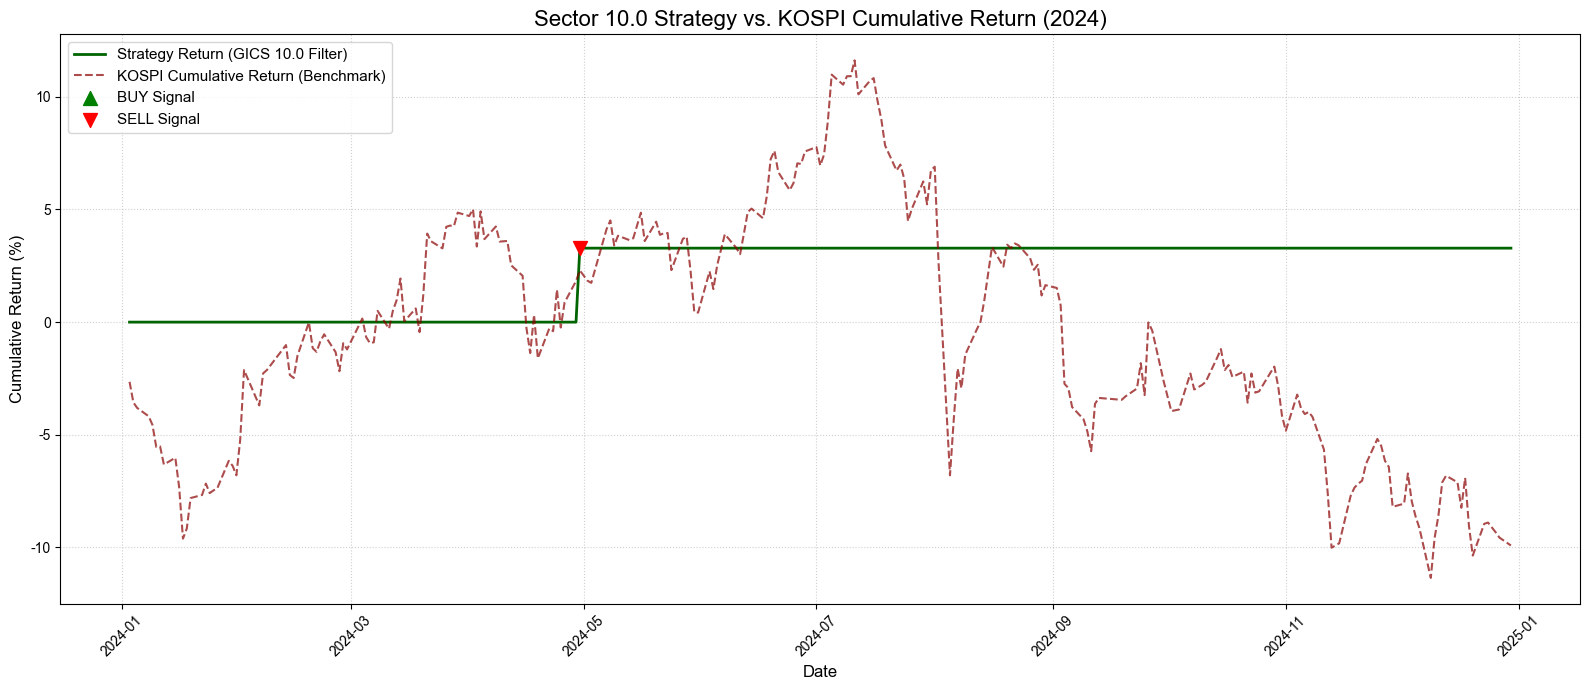

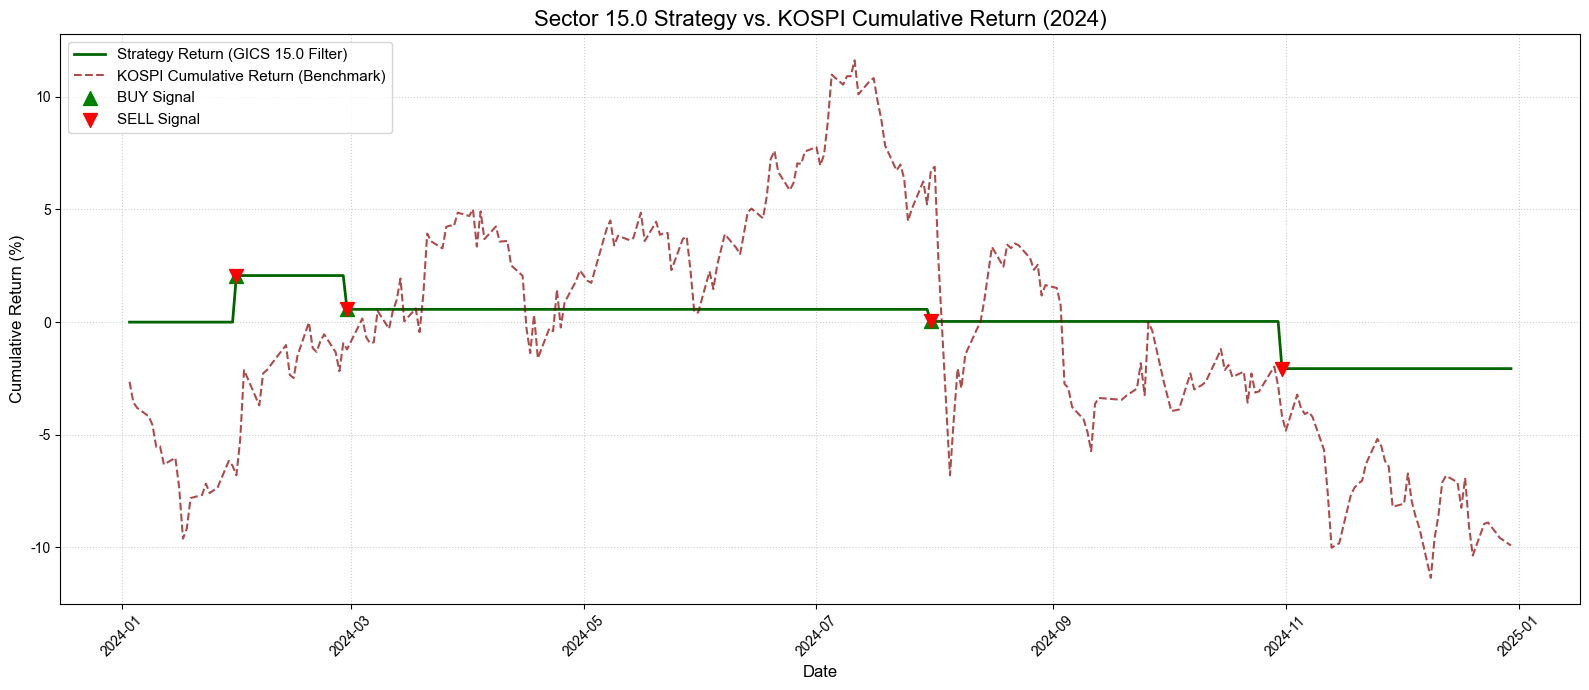

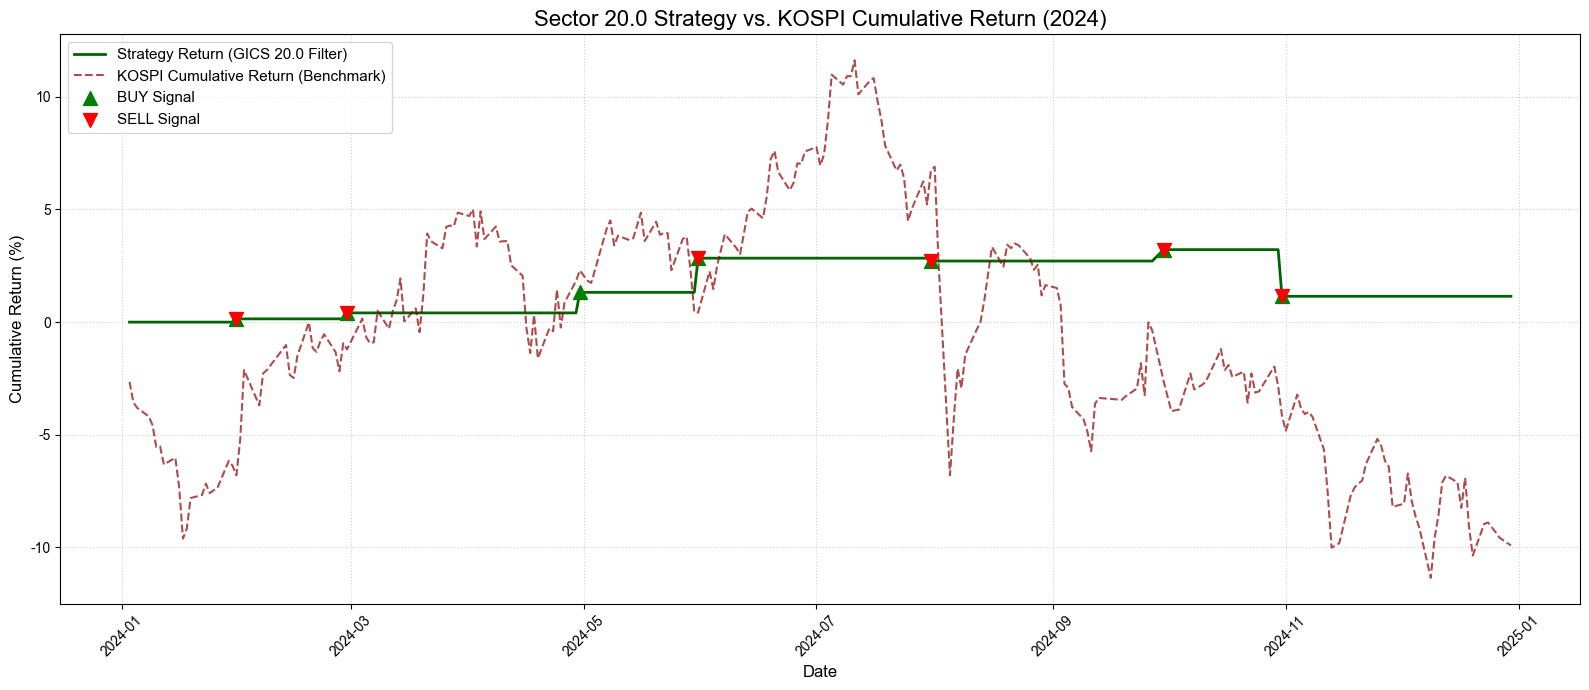

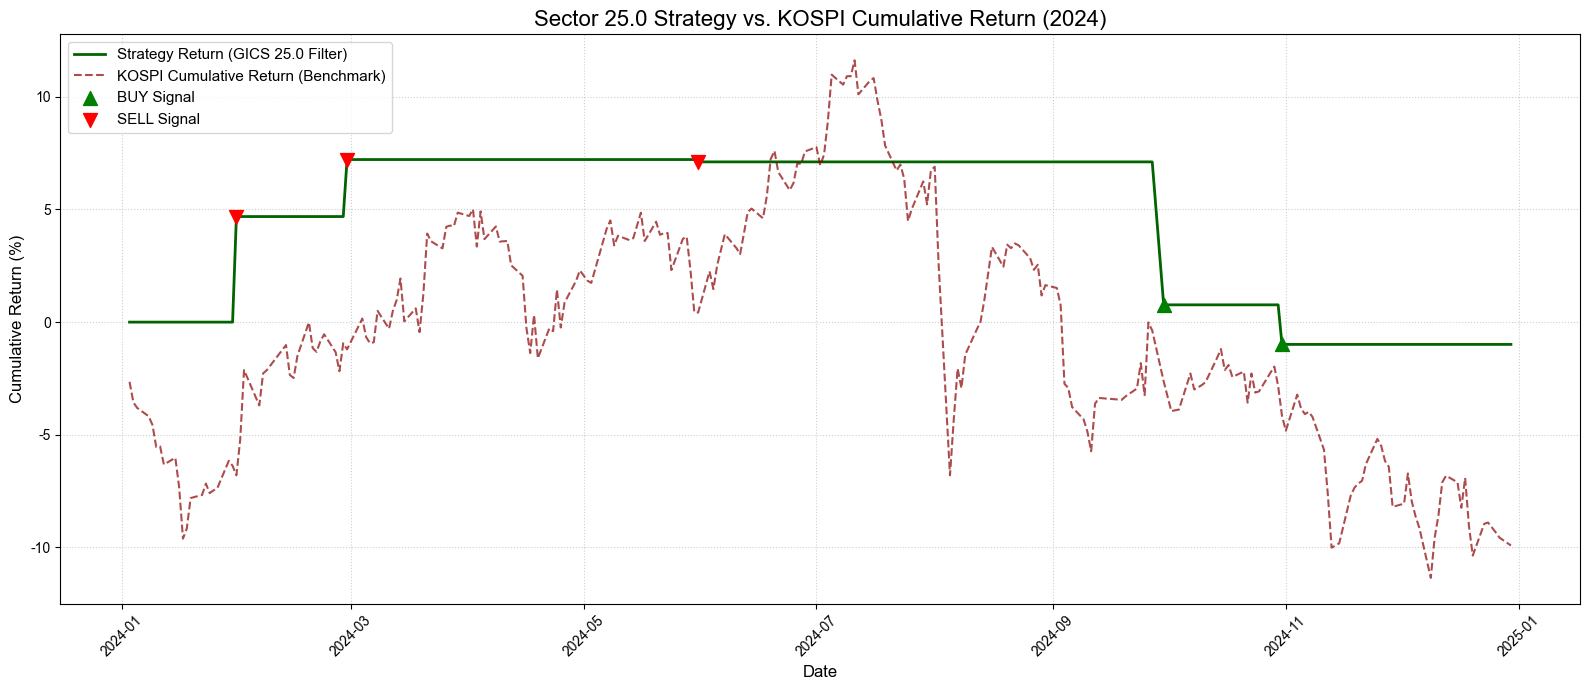

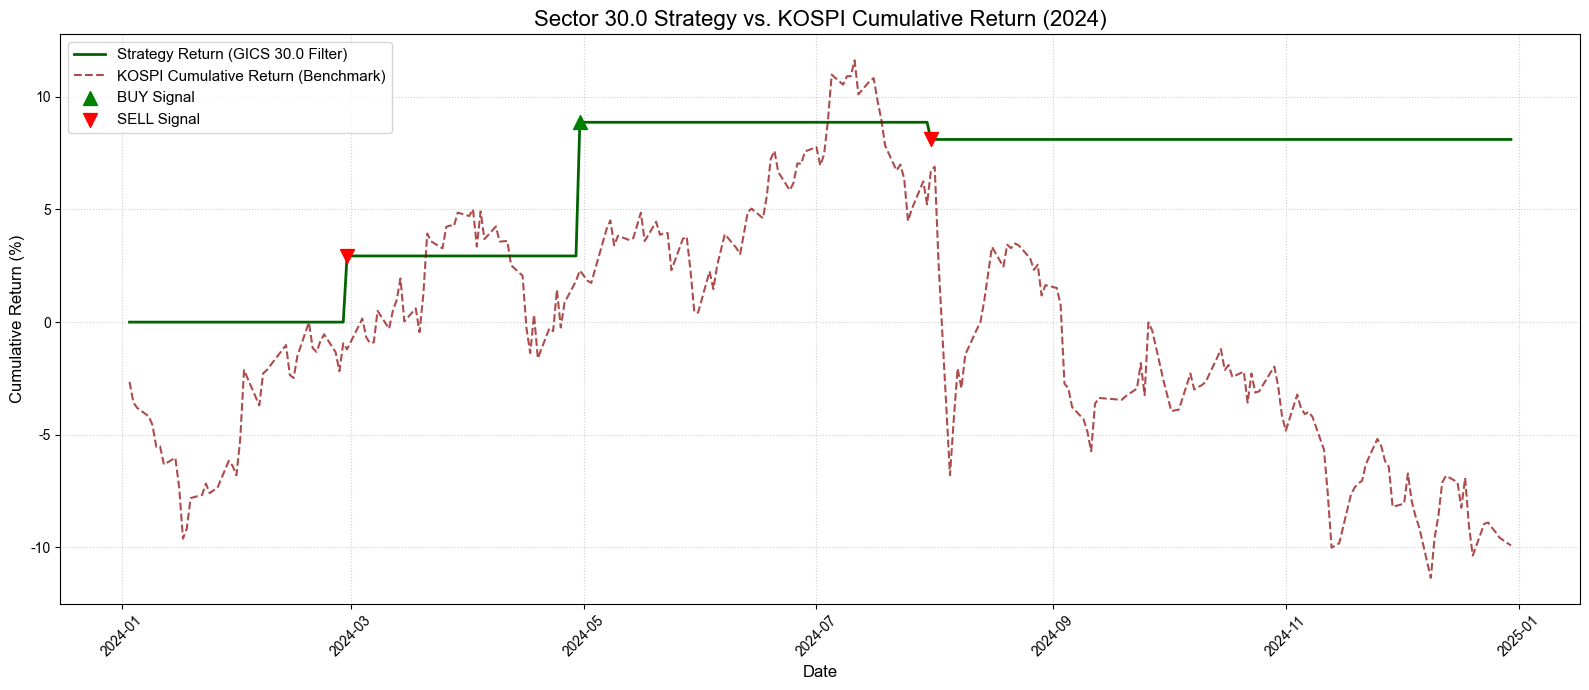

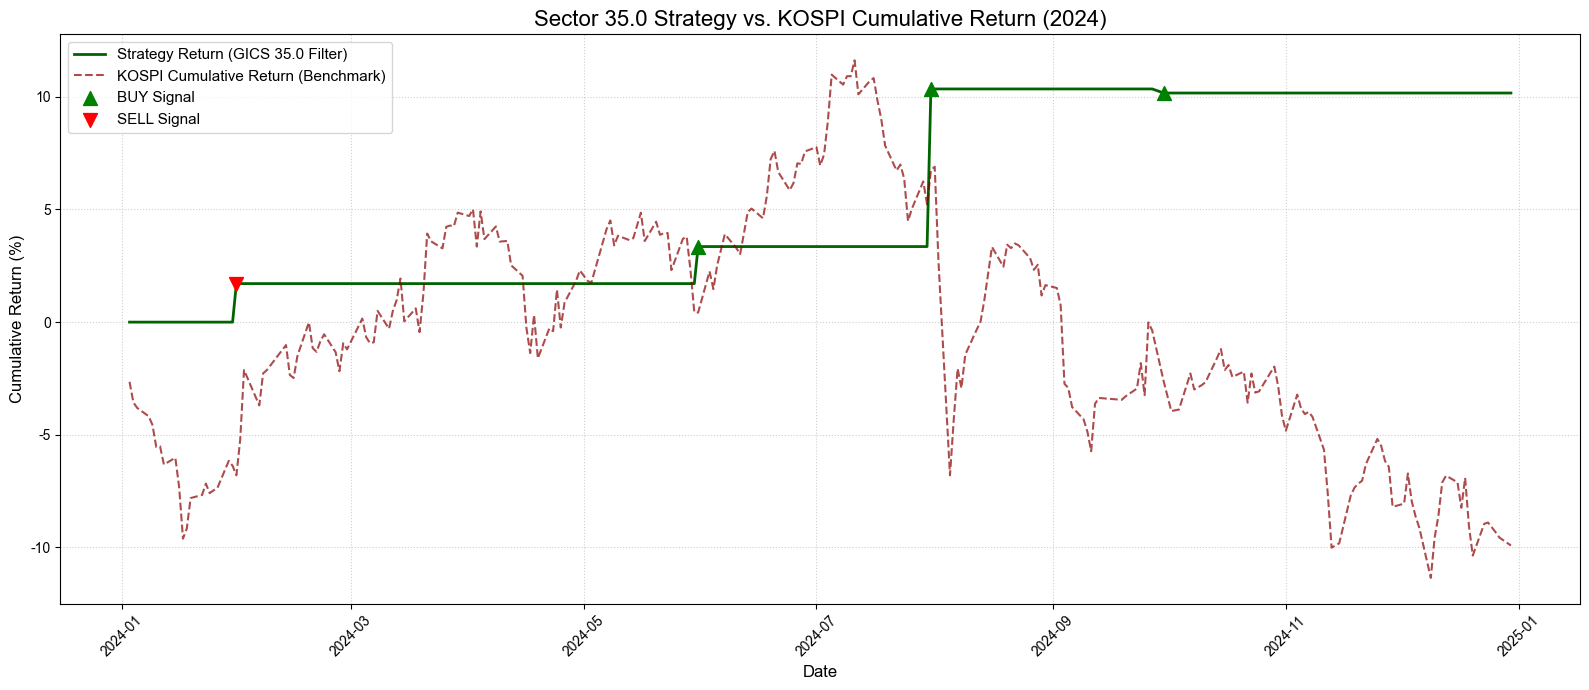

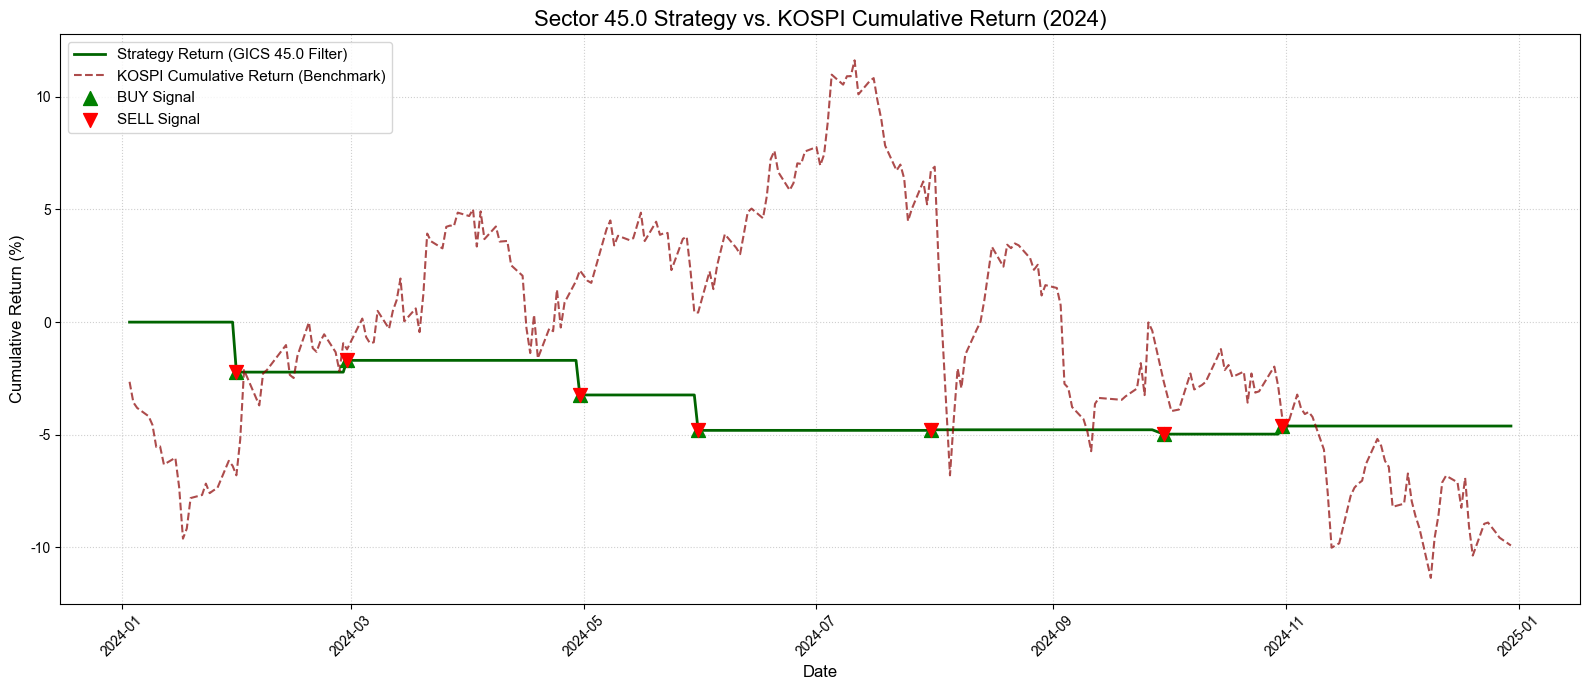

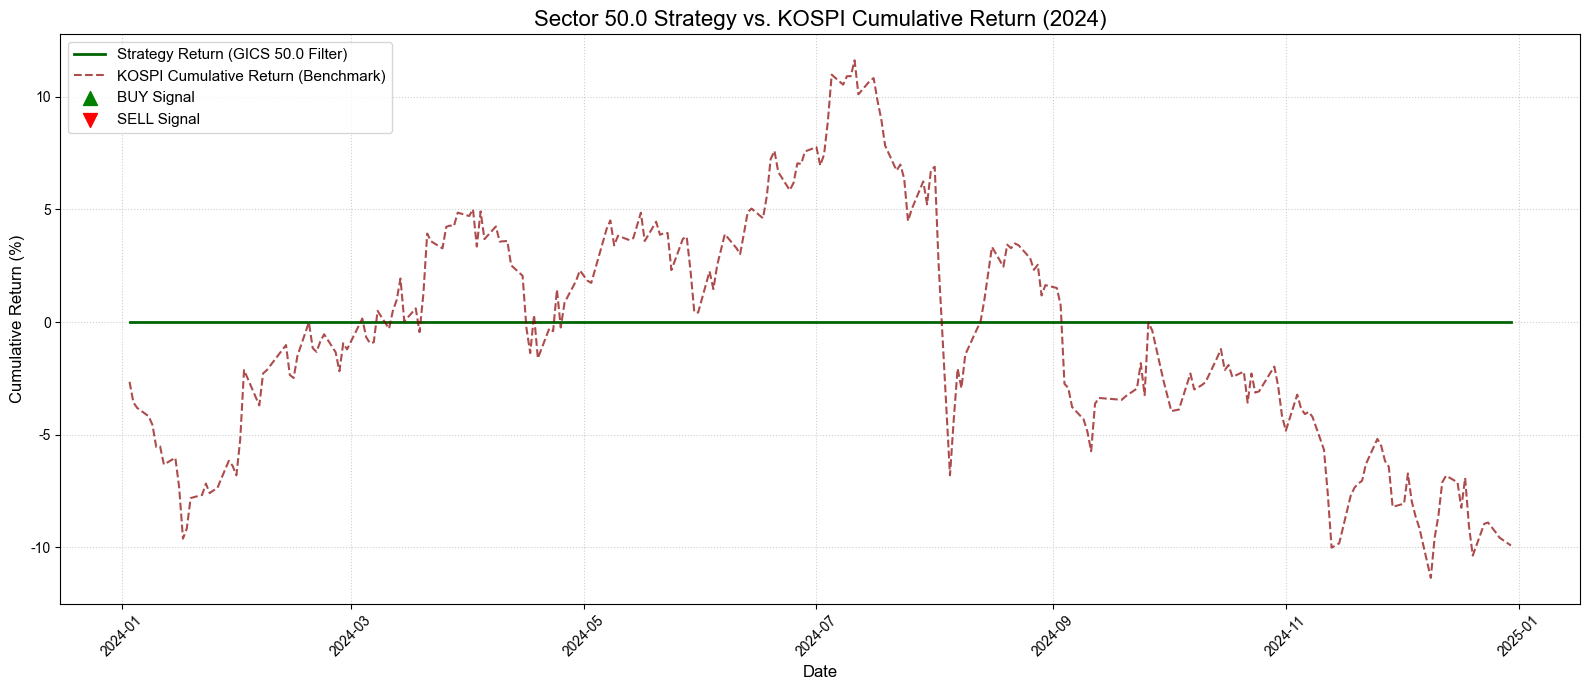


✅ 8개 Sector별 시각화 완료. 저장 폴더: ../output/problem4_backtest_all_sectors_buysell


In [20]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import rc

# --- 1. 설정 및 데이터 로드 ---
VENDOR_ANALYSIS_PATH = "../output/problem2_vendor/problem2_vendor_analysis_base.csv"
KOSPI_PATH = "../data/kospi.csv" 
GICS_PATH = "../output/gics_clean.csv"
OUT_DIR = "../output/problem4_backtest_all_sectors_buysell" 
os.makedirs(OUT_DIR, exist_ok=True)

# 규칙 설정
TARGET_GICS_LEVEL = 'sector'
Z_SCORE_THRESHOLD = 2.0
HOLDING_COLUMN = 'return_post_1d'
VALIDATION_START_DATE = pd.to_datetime('2024-01-01')

print("➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...")

try:
    # A. 분석 데이터 로드 및 분할
    df_full = pd.read_csv(
        VENDOR_ANALYSIS_PATH, 
        usecols=['symbol', 'date', 'surprise_z'] + [HOLDING_COLUMN],
        dtype={'surprise_z': np.float32, HOLDING_COLUMN: np.float64}
    ).dropna(subset=['surprise_z'] + [HOLDING_COLUMN])
    df_full['date'] = pd.to_datetime(df_full['date'])
    
    # B. KOSPI Index Load
    df_kospi = pd.read_csv(KOSPI_PATH)
    df_kospi = df_kospi.rename(columns={df_kospi.columns[0]: 'date', df_kospi.columns[1]: 'kospi_index'})
    df_kospi['date'] = pd.to_datetime(df_kospi['date'], format='%Y%m%d')
    df_kospi = df_kospi[df_kospi['date'] >= VALIDATION_START_DATE].copy()
    df_kospi['kospi_return'] = df_kospi['kospi_index'].pct_change()
    df_kospi['kospi_cumulative'] = (1 + df_kospi['kospi_return']).cumprod() - 1
    df_kospi = df_kospi.set_index('date').dropna(subset=['kospi_cumulative'])
    
    # C. GICS 정보 로드 및 병합 준비
    df_gics = pd.read_csv(GICS_PATH)
    df_gics[TARGET_GICS_LEVEL] = df_gics[TARGET_GICS_LEVEL].astype(np.float64) 
    
    df_train = df_full[df_full['date'] < VALIDATION_START_DATE].copy()
    df_validation = df_full[df_full['date'] >= VALIDATION_START_DATE].copy()
    
except Exception as e:
    print(f"❌ 오류: 데이터 로드/처리 중 오류 발생: {e}")
    exit()

# --- 2. 규칙 도출 및 데이터 준비 ---
TRAIN_MEAN_Z = df_train['surprise_z'].mean() 
TRAIN_STD_Z = df_train['surprise_z'].std() 
Z_BUY_THRESHOLD = TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z
Z_SELL_THRESHOLD = TRAIN_MEAN_Z - Z_SCORE_THRESHOLD * TRAIN_STD_Z

# GICS 정보 병합
df_validation = pd.merge(df_validation, df_gics[['symbol', TARGET_GICS_LEVEL]], on='symbol', how='left')
df_validation = df_validation.dropna(subset=[TARGET_GICS_LEVEL] + [HOLDING_COLUMN])

# A. 최종 BUY/SELL 규칙 적용
def apply_final_rule_full(row):
    if row['surprise_z'] > Z_BUY_THRESHOLD:
        return 'BUY'
    elif row['surprise_z'] < Z_SELL_THRESHOLD:
        return 'SELL'
    else:
        return 'HOLD'

df_validation['decision'] = df_validation.apply(apply_final_rule_full, axis=1)

# Matplotlib 폰트 설정 (영문 통일)
rc('font', family='Arial')
plt.rcParams['axes.unicode_minus'] = False 


# --- 3. 모든 섹터에 대한 시각화 루프 ---
unique_sectors = sorted(df_validation[TARGET_GICS_LEVEL].unique())

print(f"\n➡️ 2. {len(unique_sectors)}개 Sector별 시각화 생성 시작...")

for sector_code in unique_sectors:
    df_sector_val = df_validation[df_validation[TARGET_GICS_LEVEL] == sector_code].copy()
    
    # A. 전략 일별 수익률 Stream 생성
    df_daily_returns = df_kospi[['kospi_return', 'kospi_cumulative']].copy()
    df_daily_returns['strategy_return'] = 0.0
    
    # B. BUY/SELL 수익 반영 (SELL 수익 반전)
    df_signals = df_sector_val[df_sector_val['decision'].isin(['BUY', 'SELL'])].copy()
    
    # 전략 거래 수익률 계산 (SELL: 수익률 반전)
    df_signals['trade_return'] = np.where(
        df_signals['decision'] == 'SELL',
        -df_signals[HOLDING_COLUMN],
        df_signals[HOLDING_COLUMN]
    )

    # 시그널 발생일의 평균 전략 수익률 (Average Strategy Return per Day)
    df_signals_daily_mean = df_signals.groupby('date')['trade_return'].mean()

    for date, avg_return in df_signals_daily_mean.items():
        if date in df_daily_returns.index:
            df_daily_returns.loc[date, 'strategy_return'] = avg_return
            
    # C. 누적 수익률 계산
    df_daily_returns['strategy_cumulative'] = (1 + df_daily_returns['strategy_return']).cumprod() - 1

    # D. 시그널 마커 데이터 준비
    df_markers = df_sector_val[df_sector_val['decision'].isin(['BUY', 'SELL'])].drop_duplicates(subset=['date', 'decision']).copy()
    df_markers = pd.merge(df_markers, df_daily_returns[['strategy_cumulative']], left_on='date', right_index=True, how='inner')
    
    
    # --- E. 시각화 실행 ---
    plt.figure(figsize=(16, 7))

    # 1. Strategy Cumulative Return (녹색 실선)
    plt.plot(df_daily_returns.index, df_daily_returns['strategy_cumulative'] * 100, 
             label=f"Strategy Return (GICS {sector_code:.1f} Filter)", color='darkgreen', linewidth=2)

    # 2. KOSPI 누적 수익률 (붉은색 점선)
    plt.plot(df_kospi.index, df_kospi['kospi_cumulative'] * 100, 
             label='KOSPI Cumulative Return (Benchmark)', color='darkred', linestyle='--', alpha=0.7)

    # 3. BUY/SELL Signal Markers (시그널 표시)
    buy_markers = df_markers[df_markers['decision'] == 'BUY']
    sell_markers = df_markers[df_markers['decision'] == 'SELL']

    # BUY markers (녹색 위 삼각형)
    plt.scatter(buy_markers['date'], buy_markers['strategy_cumulative'] * 100, 
                color='green', marker='^', s=100, label='BUY Signal', zorder=5)

    # SELL markers (빨간색 아래 삼각형)
    plt.scatter(sell_markers['date'], sell_markers['strategy_cumulative'] * 100, 
                color='red', marker='v', s=100, label='SELL Signal', zorder=5)


    # 차트 꾸미기
    plt.title(f"Sector {sector_code:.1f} Strategy vs. KOSPI Cumulative Return (2024)", fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Cumulative Return (%)", fontsize=12)
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plot_path = os.path.join(OUT_DIR, f"backtest_sector_{sector_code:.1f}_buysell.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

print(f"\n✅ {len(unique_sectors)}개 Sector별 시각화 완료. 저장 폴더: {OUT_DIR}")

➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...

➡️ 2. 8개 Sector별 시각화 생성 시작...


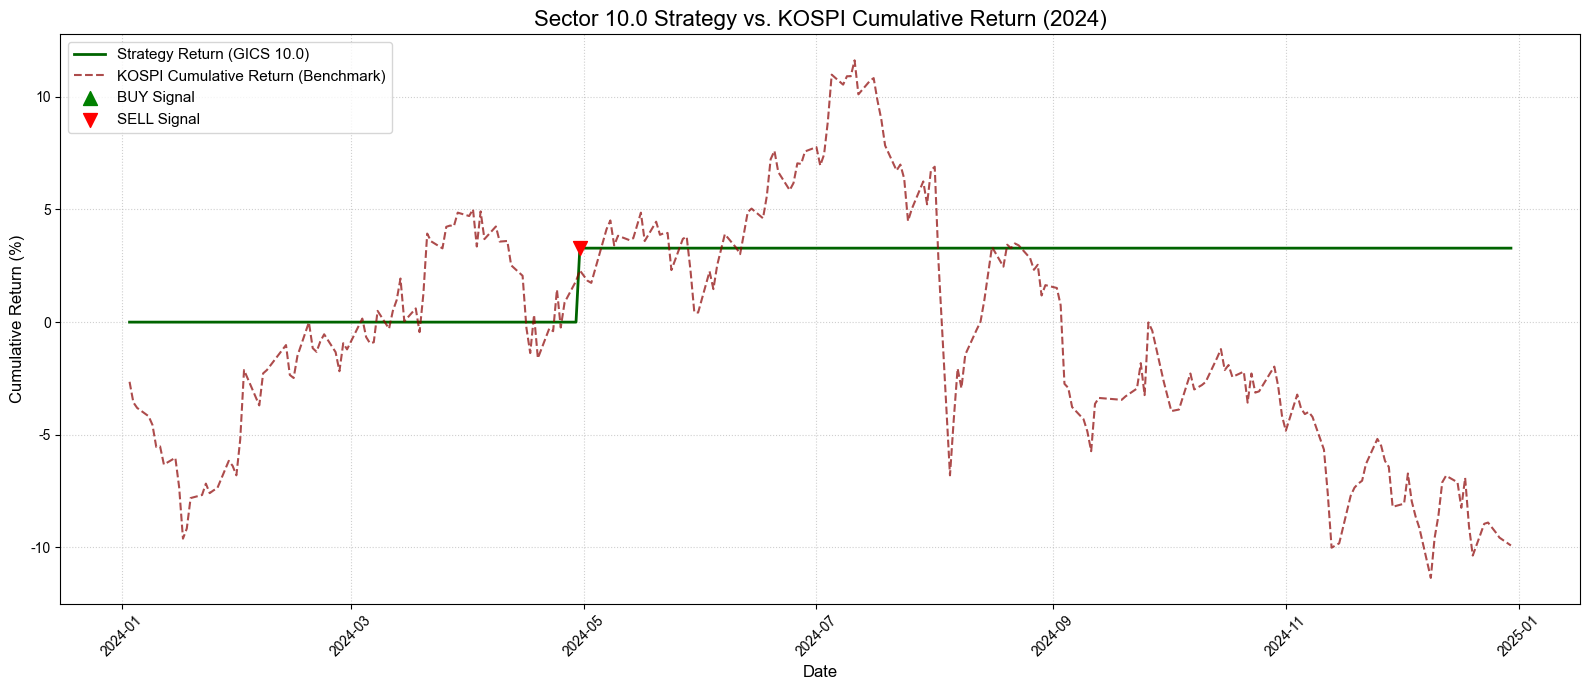

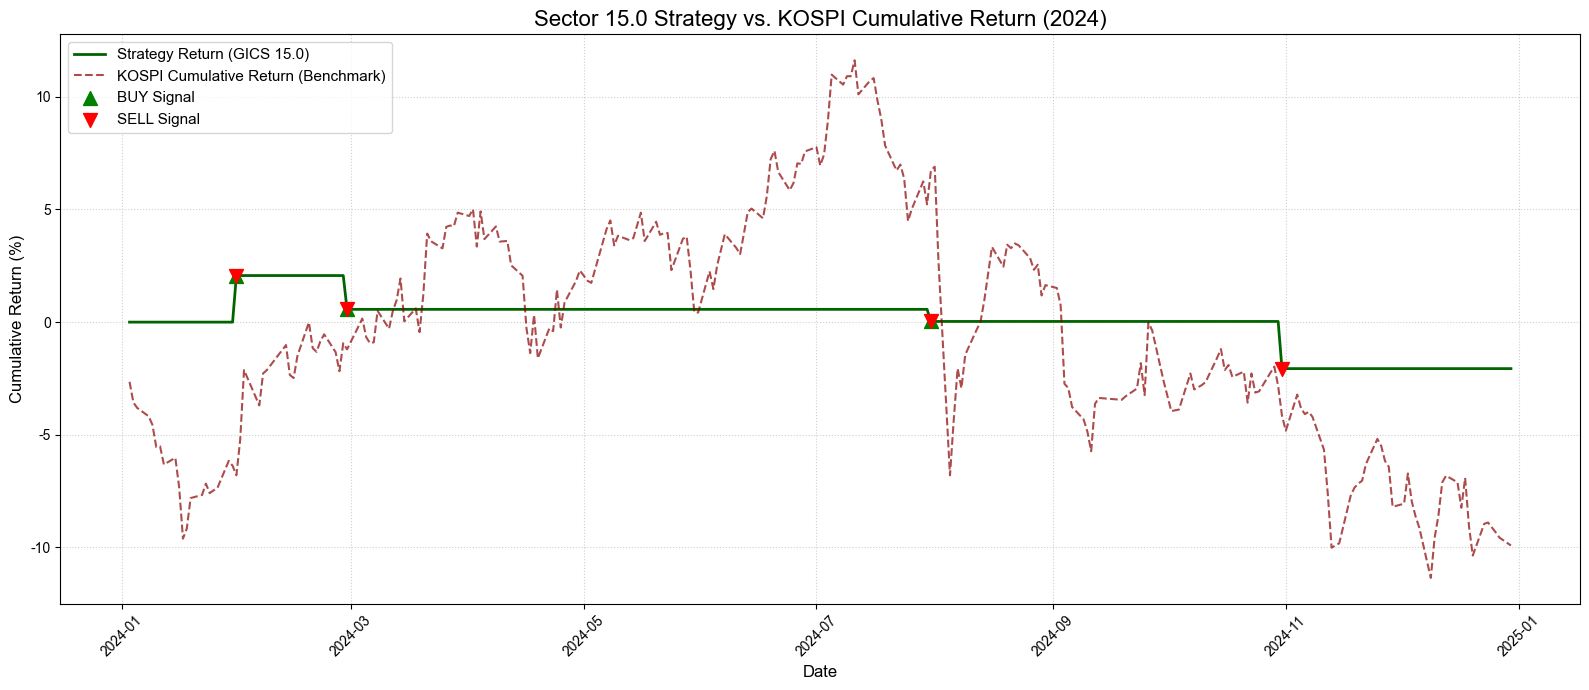

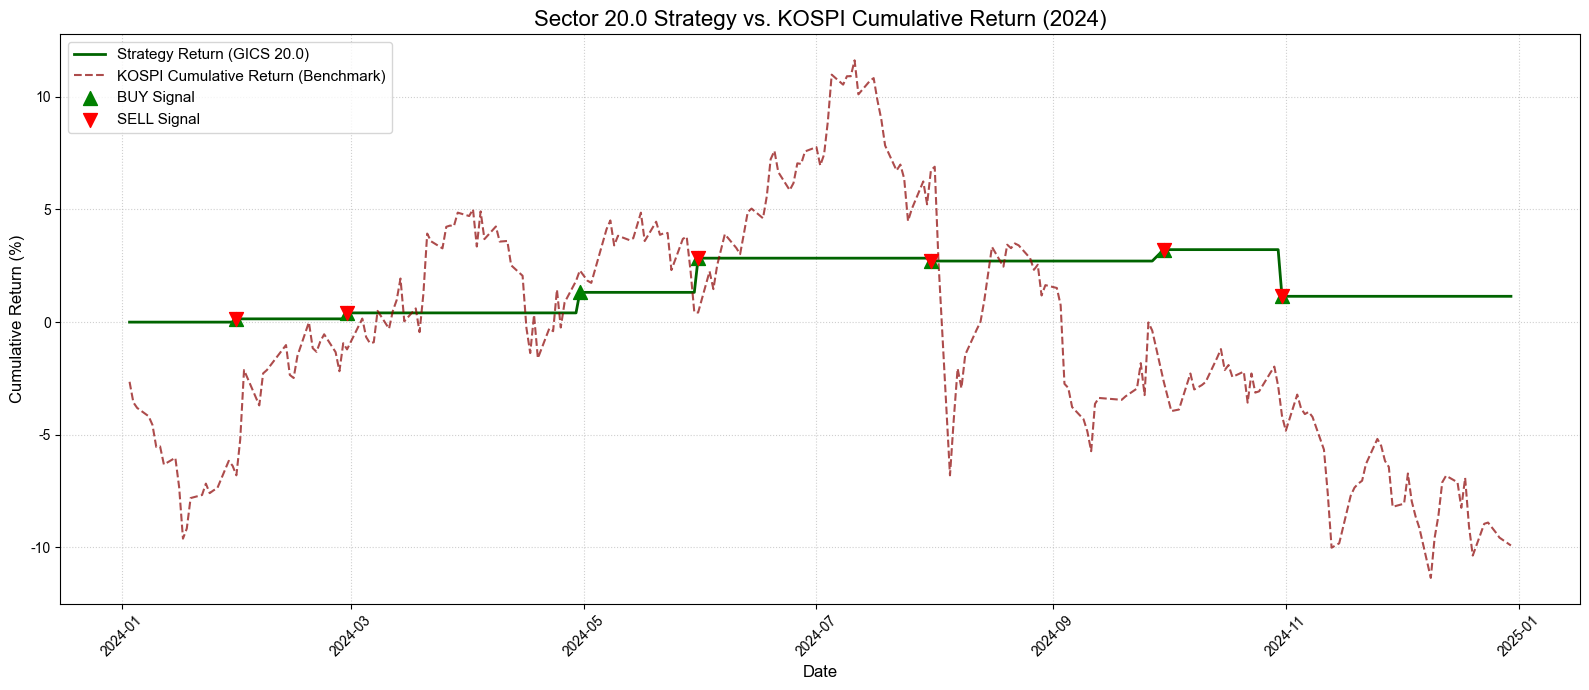

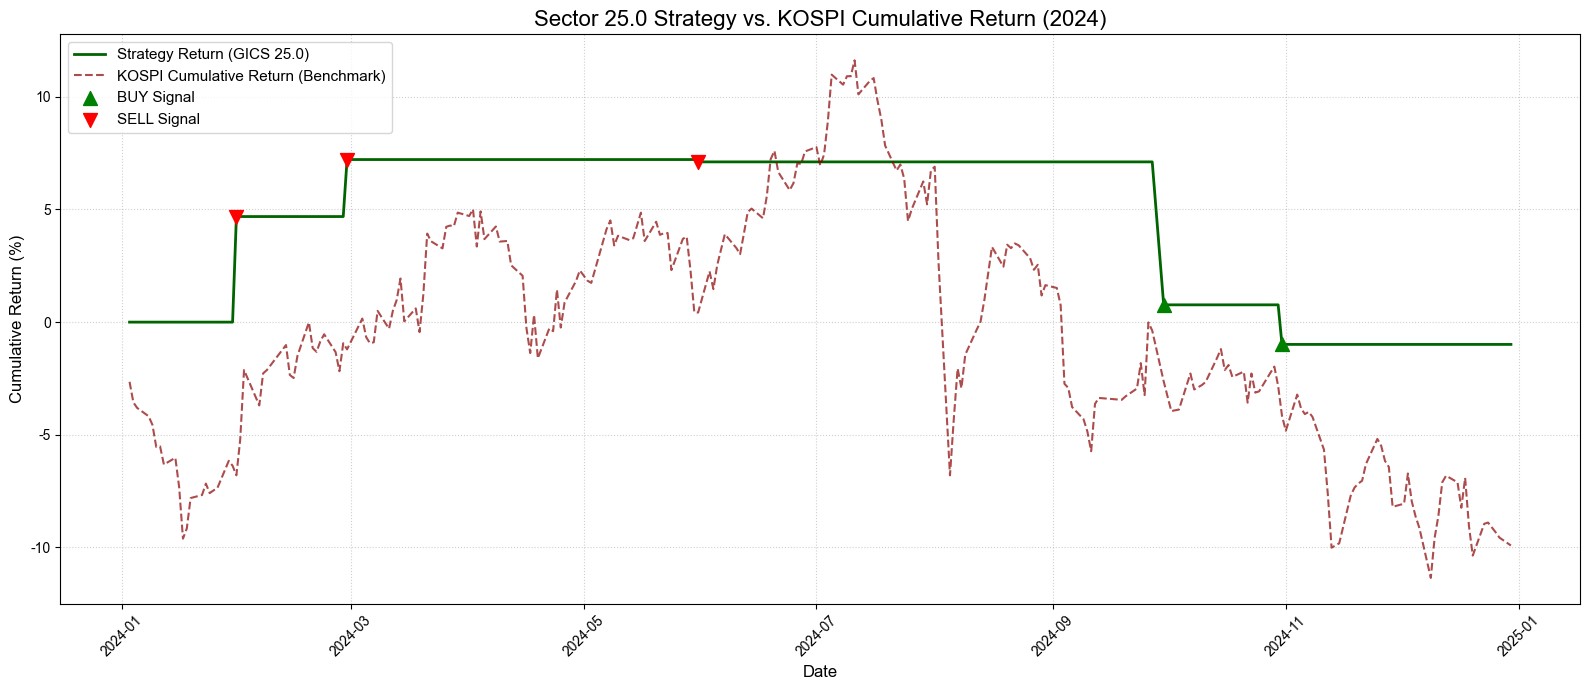

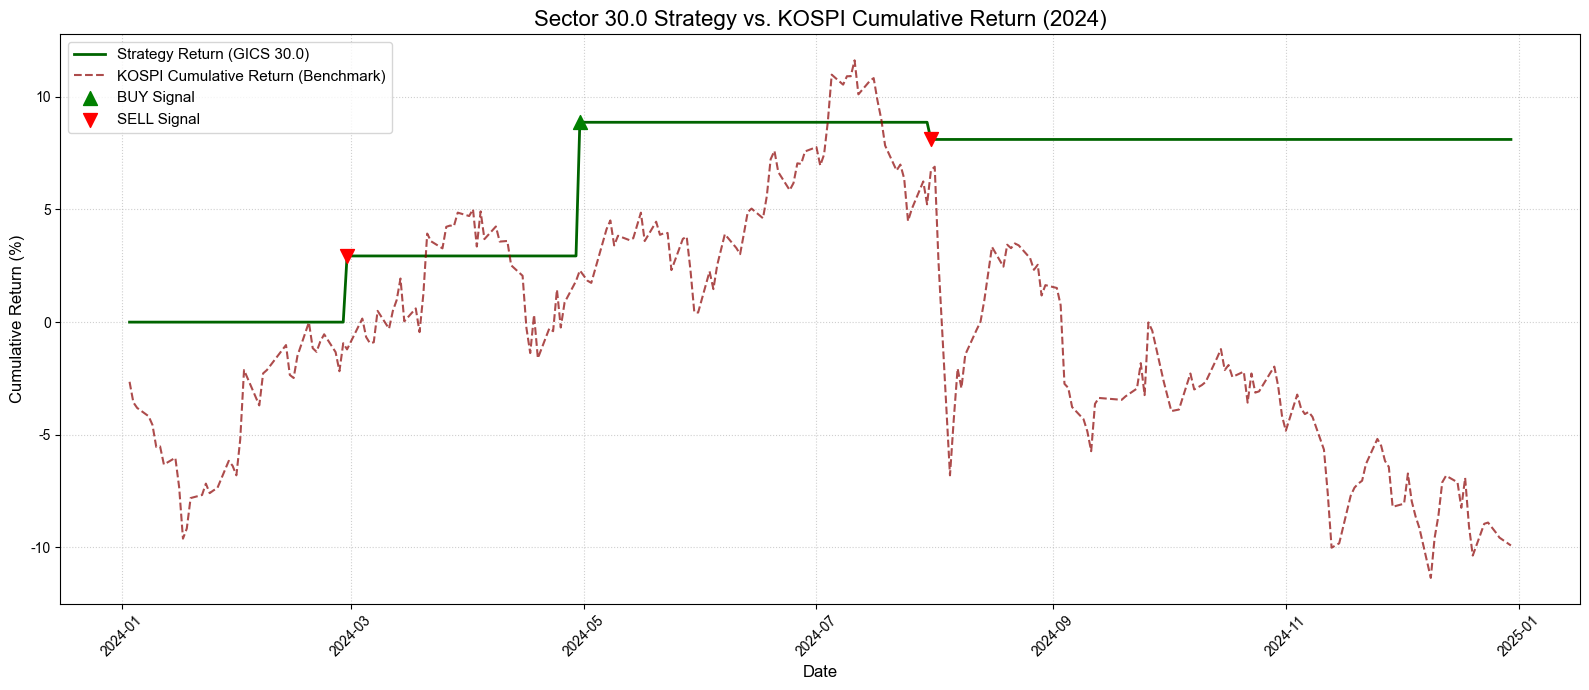

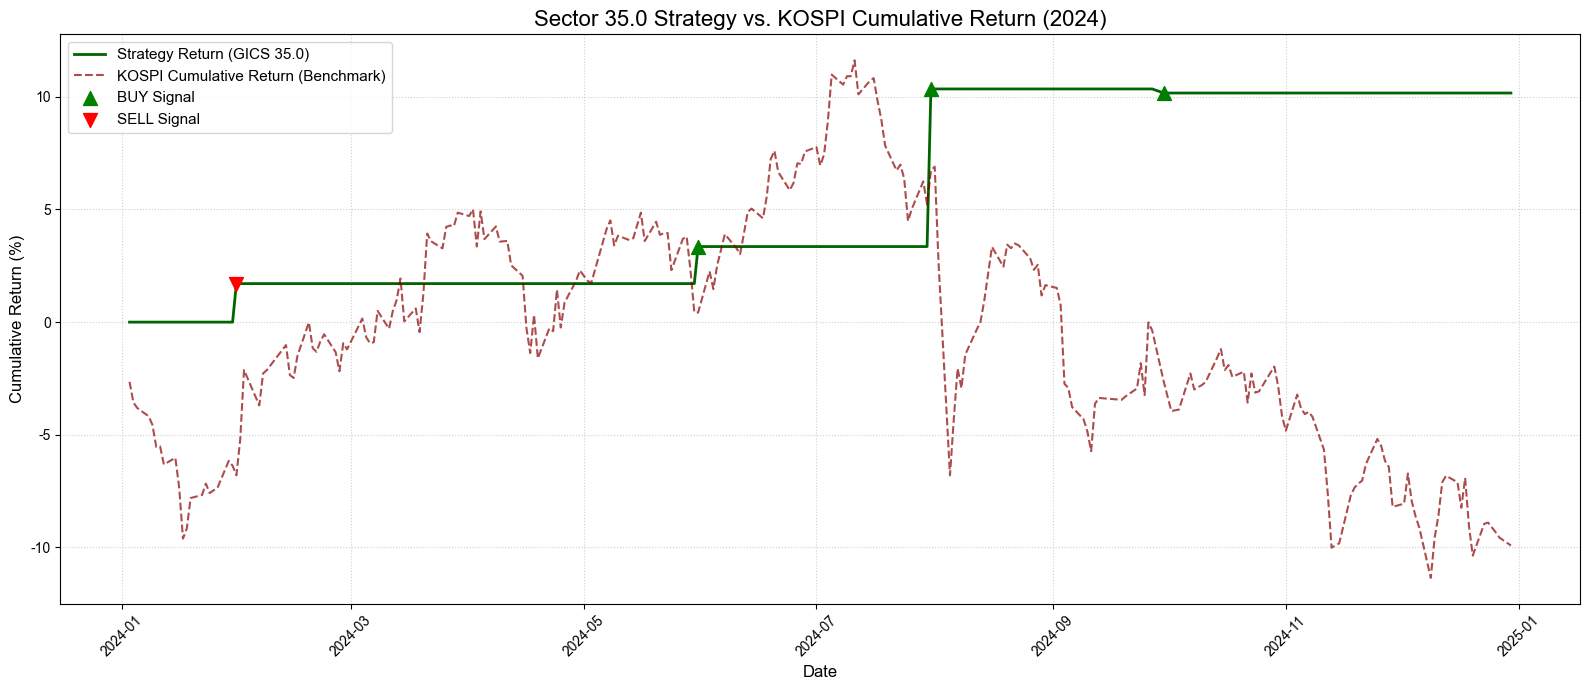

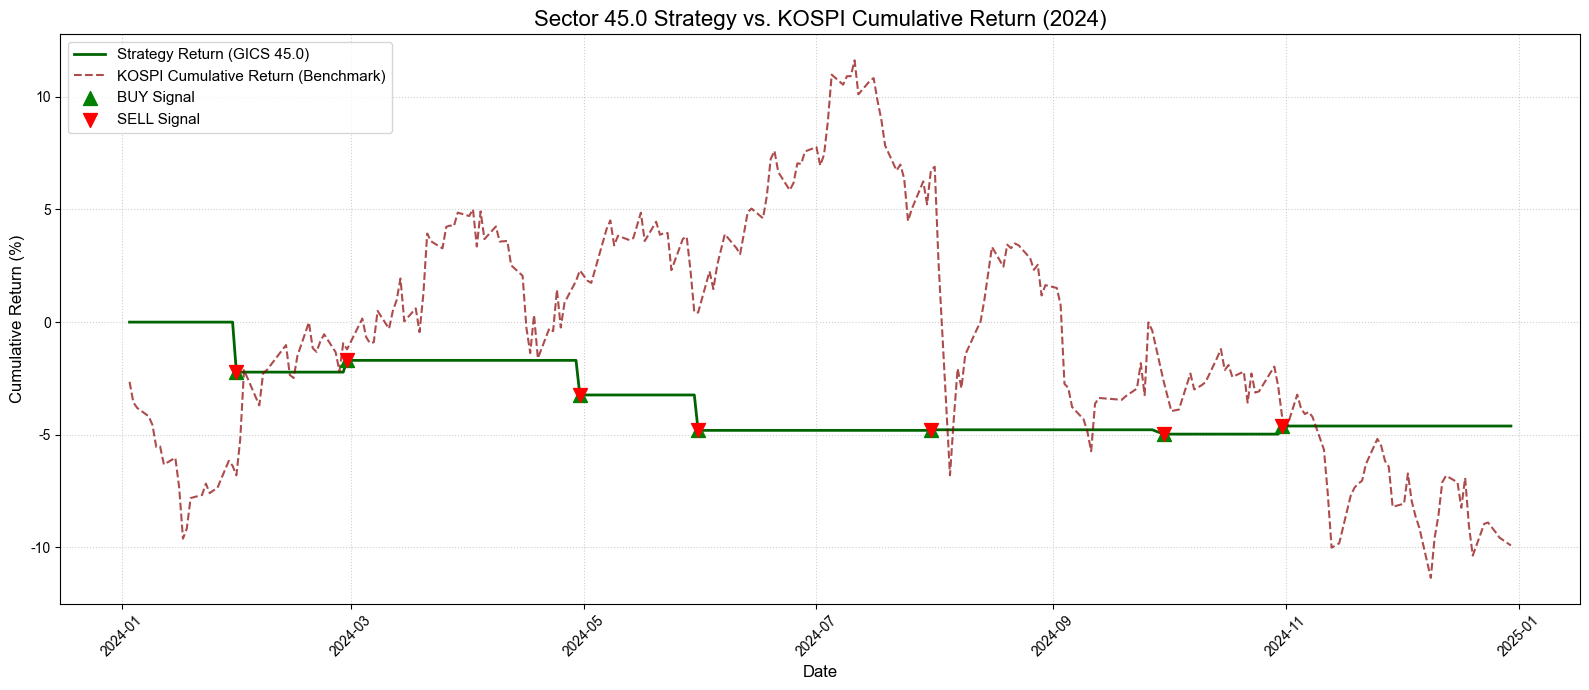

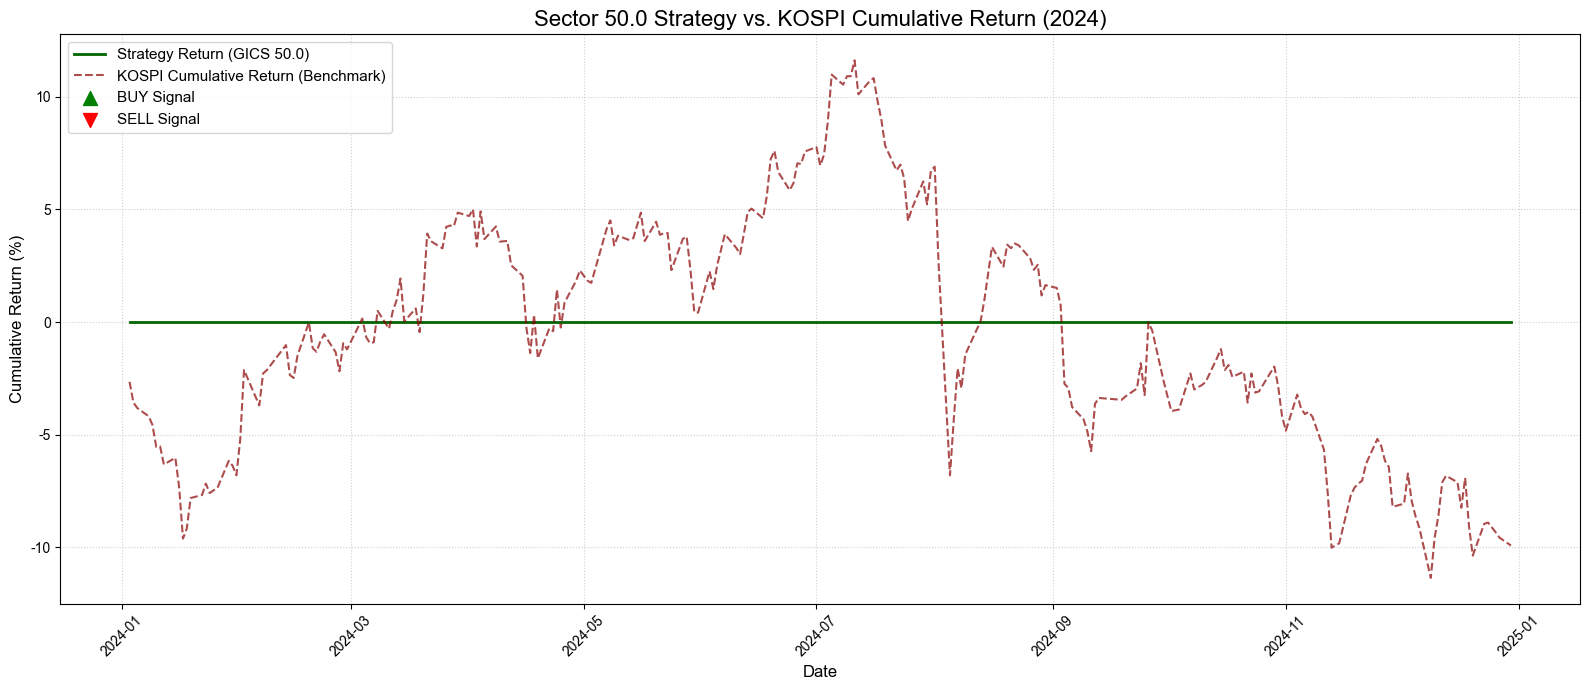


✅ 8개 Sector별 시각화 완료. 저장 폴더: ../output/problem4_backtest_all_sectors_buysell


In [21]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import rc

# --- 1. 설정 및 데이터 로드 ---
VENDOR_ANALYSIS_PATH = "../output/problem2_vendor/problem2_vendor_analysis_base.csv"
KOSPI_PATH = "../data/kospi.csv" 
GICS_PATH = "../output/gics_clean.csv"
OUT_DIR = "../output/problem4_backtest_all_sectors_buysell" 
os.makedirs(OUT_DIR, exist_ok=True)

# 규칙 설정
TARGET_GICS_LEVEL = 'sector'
Z_SCORE_THRESHOLD = 2.0
HOLDING_COLUMN = 'return_post_1d' # 시각화 기준 (1일 보유)
VALIDATION_START_DATE = pd.to_datetime('2024-01-01')

print("➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...")

try:
    # A. 분석 데이터 로드 및 분할
    df_full = pd.read_csv(
        VENDOR_ANALYSIS_PATH, 
        usecols=['symbol', 'date', 'surprise_z', HOLDING_COLUMN],
        dtype={'surprise_z': np.float32, HOLDING_COLUMN: np.float64}
    ).dropna(subset=['surprise_z', HOLDING_COLUMN])
    df_full['date'] = pd.to_datetime(df_full['date'])
    
    # B. KOSPI Index Load 및 누적 수익률 계산
    df_kospi = pd.read_csv(KOSPI_PATH)
    df_kospi = df_kospi.rename(columns={df_kospi.columns[0]: 'date', df_kospi.columns[1]: 'kospi_index'})
    df_kospi['date'] = pd.to_datetime(df_kospi['date'], format='%Y%m%d')
    df_kospi = df_kospi[df_kospi['date'] >= VALIDATION_START_DATE].copy()
    
    df_kospi['kospi_return'] = df_kospi['kospi_index'].pct_change()
    df_kospi['kospi_cumulative'] = (1 + df_kospi['kospi_return']).cumprod() - 1
    df_kospi = df_kospi.set_index('date').dropna(subset=['kospi_cumulative'])
    
    # C. GICS 정보 로드 및 병합 준비
    df_gics = pd.read_csv(GICS_PATH)
    df_gics[TARGET_GICS_LEVEL] = df_gics[TARGET_GICS_LEVEL].astype(np.float64) 
    
    # 데이터 분할
    df_train = df_full[df_full['date'] < VALIDATION_START_DATE].copy()
    df_validation = df_full[df_full['date'] >= VALIDATION_START_DATE].copy()
    
    # GICS 정보 병합
    df_validation = pd.merge(df_validation, df_gics[['symbol', TARGET_GICS_LEVEL]], on='symbol', how='left')
    df_validation = df_validation.dropna(subset=[TARGET_GICS_LEVEL, HOLDING_COLUMN])
    
except Exception as e:
    print(f"❌ 오류: 데이터 로드/처리 중 오류 발생: {e}")
    exit()

# --- 2. 규칙 도출 및 데이터 준비 ---
TRAIN_MEAN_Z = df_train['surprise_z'].mean() 
TRAIN_STD_Z = df_train['surprise_z'].std() 
Z_BUY_THRESHOLD = TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z
Z_SELL_THRESHOLD = TRAIN_MEAN_Z - Z_SCORE_THRESHOLD * TRAIN_STD_Z

# A. 최종 BUY/SELL 규칙 적용
def apply_final_rule_full(row):
    if row['surprise_z'] > Z_BUY_THRESHOLD:
        return 'BUY'
    elif row['surprise_z'] < Z_SELL_THRESHOLD:
        return 'SELL'
    else:
        return 'HOLD'

df_validation['decision'] = df_validation.apply(apply_final_rule_full, axis=1)

# Matplotlib 폰트 설정 (영문 통일)
rc('font', family='Arial')
plt.rcParams['axes.unicode_minus'] = False 


# --- 3. 모든 섹터에 대한 시각화 루프 ---
unique_sectors = sorted(df_validation[TARGET_GICS_LEVEL].unique())

print(f"\n➡️ 2. {len(unique_sectors)}개 Sector별 시각화 생성 시작...")

for sector_code in unique_sectors:
    df_sector_val = df_validation[df_validation[TARGET_GICS_LEVEL] == sector_code].copy()
    
    # A. BUY/SELL 시그널 분리
    df_signals = df_sector_val[df_sector_val['decision'].isin(['BUY', 'SELL'])].copy()
    
    # B. 전략 일별 수익률 Stream 계산 (SELL 수익 반전)
    df_daily_returns = df_kospi[['kospi_return', 'kospi_cumulative']].copy()
    df_daily_returns['strategy_return'] = 0.0
    
    df_signals['trade_return'] = np.where(
        df_signals['decision'] == 'SELL',
        -df_signals[HOLDING_COLUMN],
        df_signals[HOLDING_COLUMN]
    )

    df_signals_daily_mean = df_signals.groupby('date')['trade_return'].mean()

    for date, avg_return in df_signals_daily_mean.items():
        if date in df_daily_returns.index:
            df_daily_returns.loc[date, 'strategy_return'] = avg_return
            
    # C. 누적 수익률 계산
    df_daily_returns['strategy_cumulative'] = (1 + df_daily_returns['strategy_return']).cumprod() - 1

    # D. 시그널 마커 데이터 준비
    df_markers = df_sector_val[df_sector_val['decision'].isin(['BUY', 'SELL'])].drop_duplicates(subset=['date', 'decision']).copy()
    df_markers = pd.merge(df_markers, df_daily_returns[['strategy_cumulative']], left_on='date', right_index=True, how='inner')
    
    
    # --- E. 시각화 실행 ---
    plt.figure(figsize=(16, 7))

    # 1. Strategy Cumulative Return (녹색 실선)
    plt.plot(df_daily_returns.index, df_daily_returns['strategy_cumulative'] * 100, 
             label=f"Strategy Return (GICS {sector_code:.1f})", color='darkgreen', linewidth=2)

    # 2. KOSPI 누적 수익률 (붉은색 점선)
    plt.plot(df_kospi.index, df_kospi['kospi_cumulative'] * 100, 
             label='KOSPI Cumulative Return (Benchmark)', color='darkred', linestyle='--', alpha=0.7)

    # 3. BUY/SELL Signal Markers (시그널 표시)
    buy_markers = df_markers[df_markers['decision'] == 'BUY']
    sell_markers = df_markers[df_markers['decision'] == 'SELL']

    # BUY markers (녹색 위 삼각형)
    plt.scatter(buy_markers['date'], buy_markers['strategy_cumulative'] * 100, 
                color='green', marker='^', s=100, label='BUY Signal', zorder=5)

    # SELL markers (빨간색 아래 삼각형)
    plt.scatter(sell_markers['date'], sell_markers['strategy_cumulative'] * 100, 
                color='red', marker='v', s=100, label='SELL Signal', zorder=5)


    # 차트 꾸미기
    plt.title(f"Sector {sector_code:.1f} Strategy vs. KOSPI Cumulative Return (2024)", fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Cumulative Return (%)", fontsize=12)
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plot_path = os.path.join(OUT_DIR, f"backtest_sector_{sector_code:.1f}_buysell.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

print(f"\n✅ {len(unique_sectors)}개 Sector별 시각화 완료. 저장 폴더: {OUT_DIR}")


➡️ 1. 8개 Sector별 BUY/SELL 백테스팅 시각화 생성 시작...


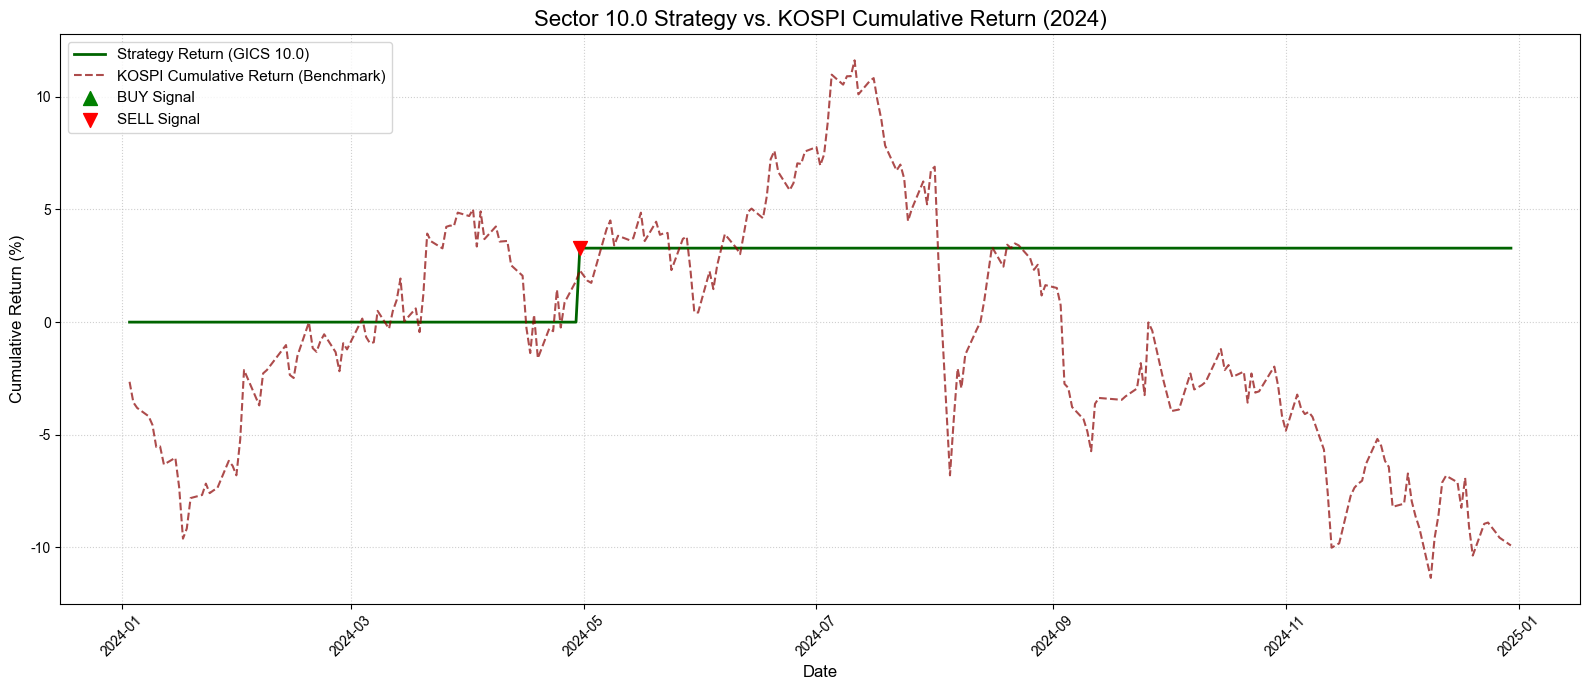

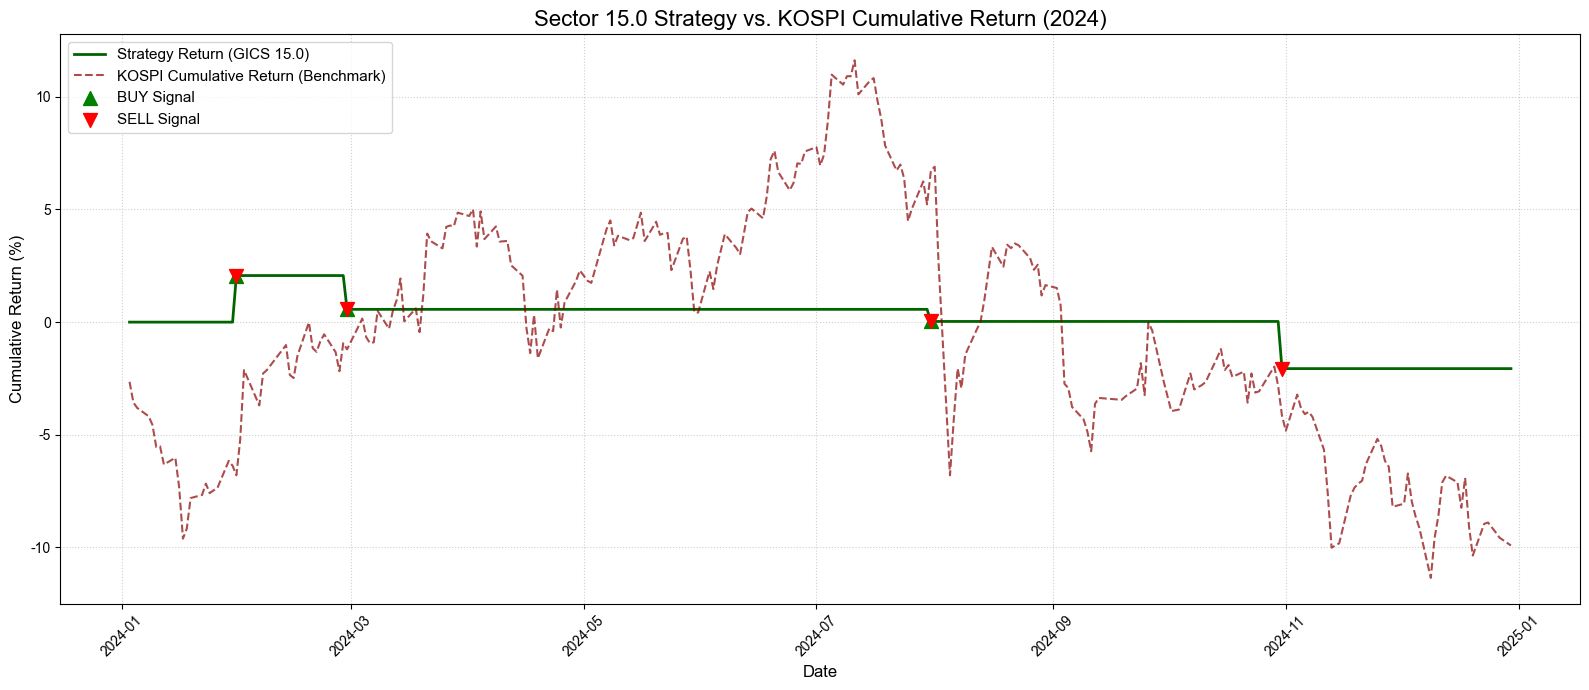

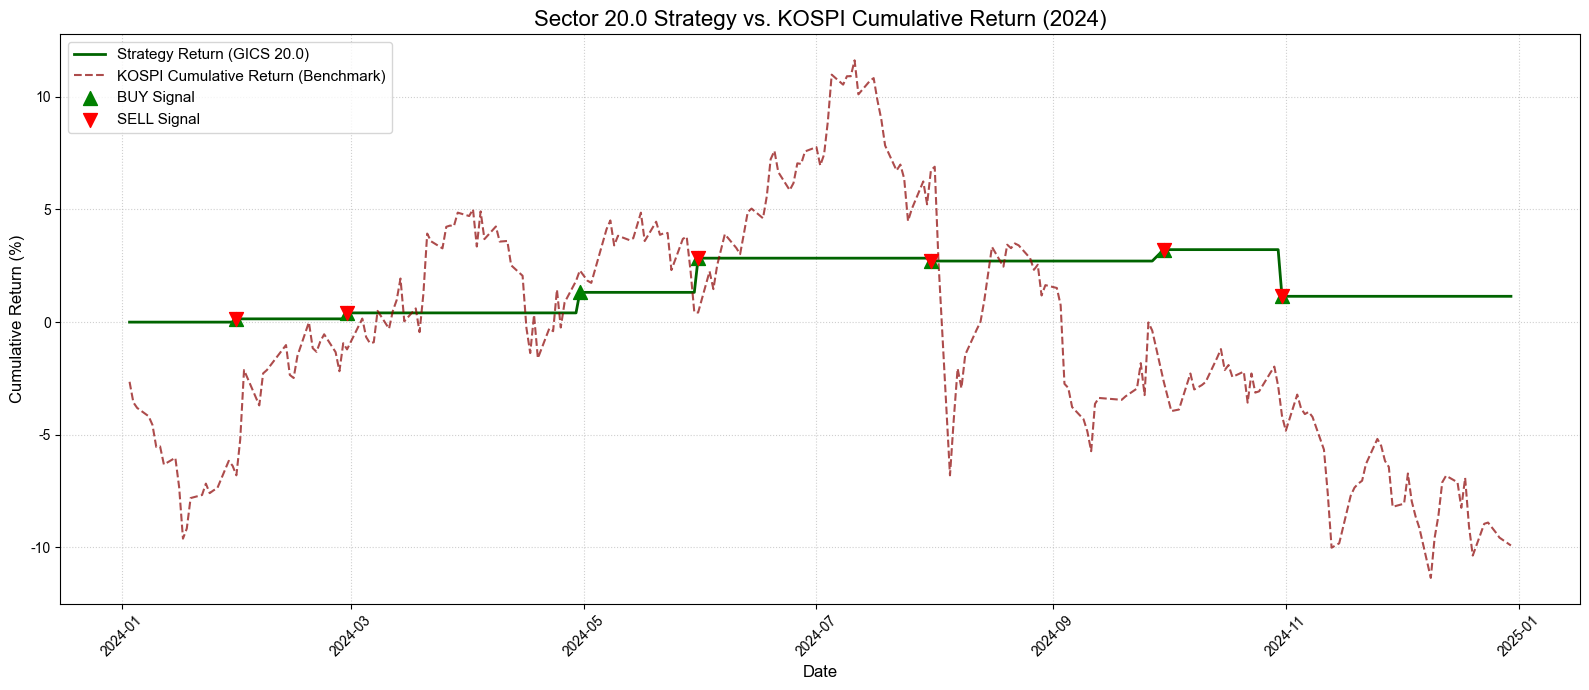

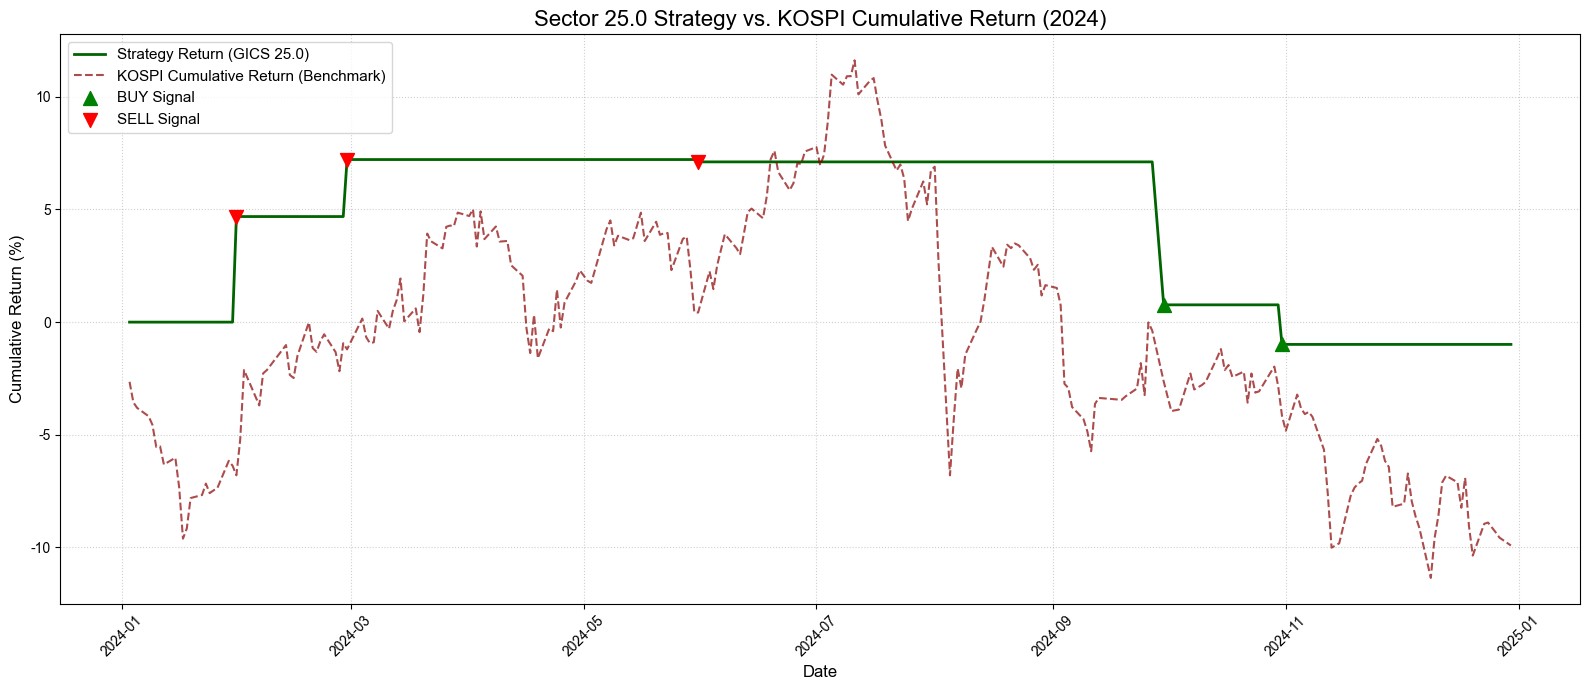

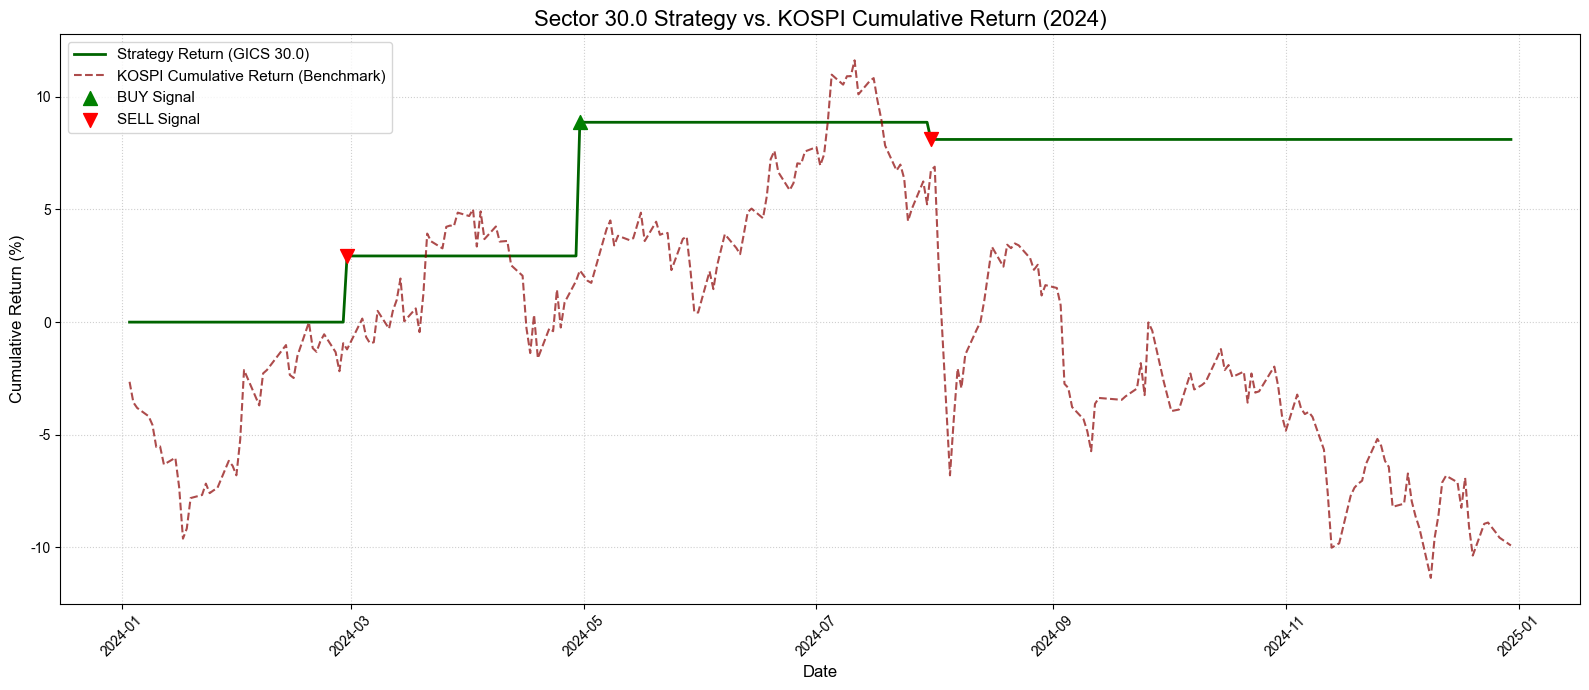

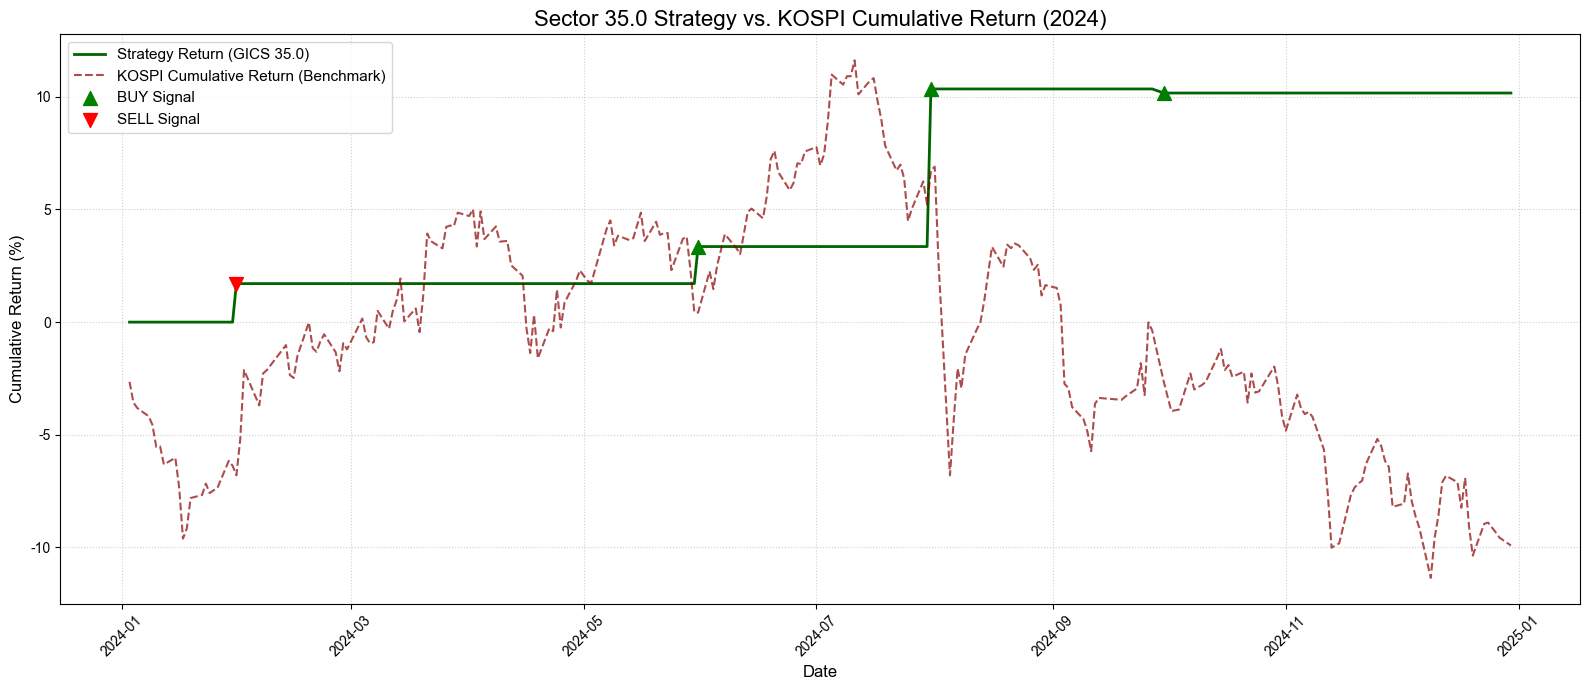

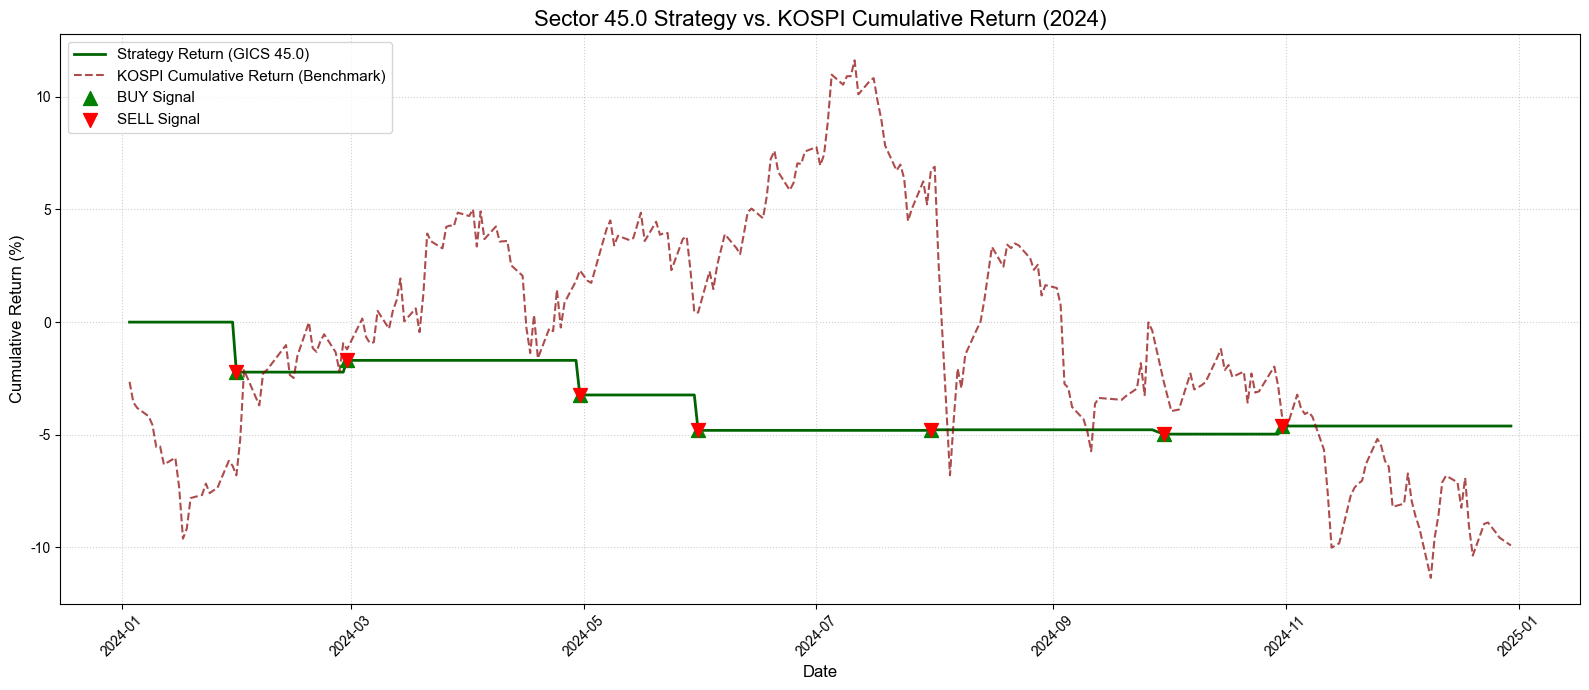

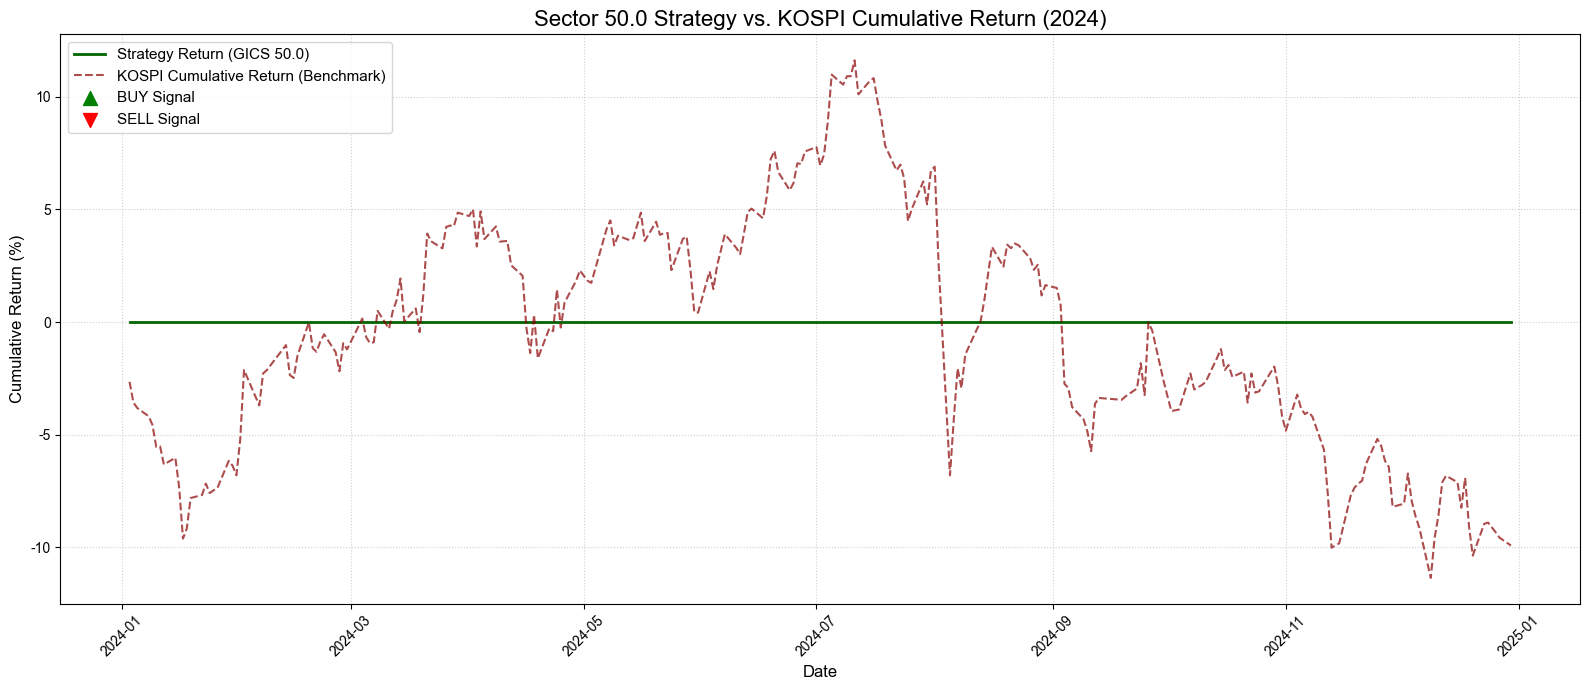


✅ 8개 Sector별 시각화 완료. 저장 폴더: ../output/problem4_backtest_all_sectors_buysell


In [24]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import font_manager 

# --- 설정 및 규칙 상수 ---
TARGET_GICS_LEVEL = 'sector'
Z_SCORE_THRESHOLD = 2.0
OUT_DIR = "../output/problem4_backtest_all_sectors_buysell" 
os.makedirs(OUT_DIR, exist_ok=True)

# Matplotlib 폰트 설정 (영문 통일)
rc('font', family='Arial')
plt.rcParams['axes.unicode_minus'] = False 


# --- 1. 모든 섹터에 대한 시각화 루프 ---
unique_sectors = sorted(df_validation[TARGET_GICS_LEVEL].unique())

print(f"\n➡️ 1. {len(unique_sectors)}개 Sector별 BUY/SELL 백테스팅 시각화 생성 시작...")

for sector_code in unique_sectors:
    df_sector_val = df_validation[df_validation[TARGET_GICS_LEVEL] == sector_code].copy()
    
    # A. BUY/SELL 시그널 분류 (훈련 통계치 기준)
    is_buy = df_sector_val['surprise_z'] > TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z
    is_sell = df_sector_val['surprise_z'] < TRAIN_MEAN_Z - Z_SCORE_THRESHOLD * TRAIN_STD_Z

    df_sector_val['decision'] = np.select([is_buy, is_sell], ['BUY', 'SELL'], default='HOLD')
    
    # B. 전략 일별 수익률 Stream 생성
    df_daily_returns = df_kospi[['kospi_return', 'kospi_cumulative']].copy()
    df_daily_returns['strategy_return'] = 0.0
    
    # C. BUY/SELL 수익 반영 (SELL 수익 반전)
    df_signals = df_sector_val[df_sector_val['decision'].isin(['BUY', 'SELL'])].copy()
    
    # 전략 거래 수익률 계산 (SELL: 수익률 반전)
    df_signals['trade_return'] = np.where(
        df_signals['decision'] == 'SELL',
        -df_signals['return_post_1d'], # Short Profit
        df_signals['return_post_1d'] # Long Profit
    )

    # 시그널 발생일의 평균 전략 수익률 (Average Strategy Return per Day)
    df_signals_daily_mean = df_signals.groupby('date')['trade_return'].mean()

    for date, avg_return in df_signals_daily_mean.items():
        if date in df_daily_returns.index:
            df_daily_returns.loc[date, 'strategy_return'] = avg_return
            
    # D. 누적 수익률 계산
    df_daily_returns['strategy_cumulative'] = (1 + df_daily_returns['strategy_return']).cumprod() - 1

    # E. 시그널 마커 데이터 준비
    df_markers = df_sector_val[df_sector_val['decision'].isin(['BUY', 'SELL'])].drop_duplicates(subset=['date', 'decision']).copy()
    df_markers = pd.merge(df_markers, df_daily_returns[['strategy_cumulative']], left_on='date', right_index=True, how='inner')
    
    
    # --- F. 시각화 실행 ---
    plt.figure(figsize=(16, 7))

    # 1. Strategy Cumulative Return (녹색 실선)
    plt.plot(df_daily_returns.index, df_daily_returns['strategy_cumulative'] * 100, 
             label=f"Strategy Return (GICS {sector_code:.1f})", color='darkgreen', linewidth=2)

    # 2. KOSPI 누적 수익률 (붉은색 점선)
    plt.plot(df_kospi.index, df_kospi['kospi_cumulative'] * 100, 
             label='KOSPI Cumulative Return (Benchmark)', color='darkred', linestyle='--', alpha=0.7)

    # 3. BUY/SELL Signal Markers (시그널 표시)
    buy_markers = df_markers[df_markers['decision'] == 'BUY']
    sell_markers = df_markers[df_markers['decision'] == 'SELL']

    # BUY markers (녹색 위 삼각형)
    plt.scatter(buy_markers['date'], buy_markers['strategy_cumulative'] * 100, 
                color='green', marker='^', s=100, label='BUY Signal', zorder=5)

    # SELL markers (빨간색 아래 삼각형)
    plt.scatter(sell_markers['date'], sell_markers['strategy_cumulative'] * 100, 
                color='red', marker='v', s=100, label='SELL Signal', zorder=5)


    # 차트 꾸미기
    plt.title(f"Sector {sector_code:.1f} Strategy vs. KOSPI Cumulative Return (2024)", fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Cumulative Return (%)", fontsize=12)
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plot_path = os.path.join(OUT_DIR, f"backtest_sector_{sector_code:.1f}_buysell.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

print(f"\n✅ {len(unique_sectors)}개 Sector별 시각화 완료. 저장 폴더: {OUT_DIR}")


➡️ 1. 8개 Sector별 다기간 전략 시각화 시작...
⚠️ Sector 10.0: BUY 시그널이 없어 시각화 생략.


KeyError: "['return_post_5d'] not in index"

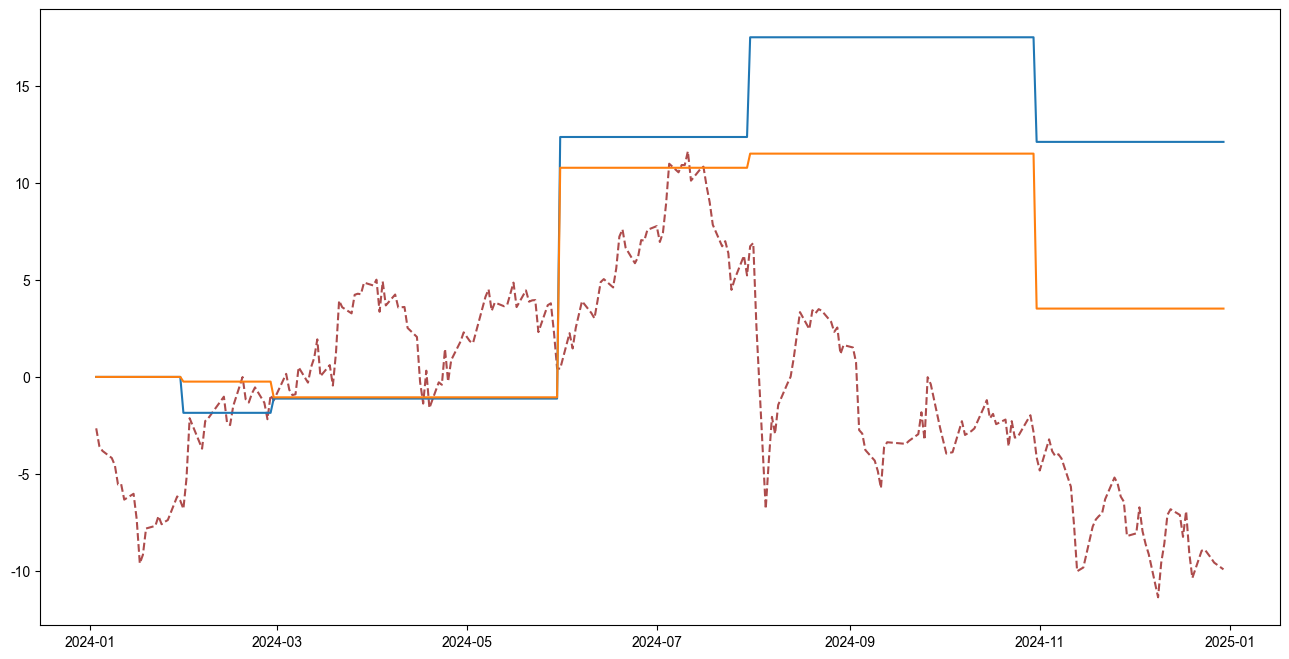

In [28]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import font_manager 

# --- 1. 설정 및 데이터 로드 (변수 정의는 이전 셀에서 완료 가정) ---
VENDOR_ANALYSIS_PATH = "../output/problem2_vendor/problem2_vendor_analysis_base.csv"
KOSPI_PATH = "../data/kospi.csv" 
GICS_PATH = "../output/gics_clean.csv"
OUT_DIR = "../output/problem4_retention_analysis_all_sectors_combined" 
os.makedirs(OUT_DIR, exist_ok=True)

# 규칙 설정 (이전 단계에서 확정된 변수 재사용)
TARGET_GICS_LEVEL = 'sector'
Z_SCORE_THRESHOLD = 2.0
RETURN_COLUMNS_ALL = ['return_post_1d', 'return_post_2d', 'return_post_5d', 'return_post_10d', 'return_post_20d']
HOLDING_PERIODS = [1, 2, 5, 10, 20] 
VALIDATION_START_DATE = pd.to_datetime('2024-01-01')


# --- 2. 데이터 로드 및 규칙 도출 (이전 단계와 동일 로직) ---
# NOTE: 이 부분은 Jupyter 환경에서 df_validation, df_kospi, TRAIN_MEAN_Z, TRAIN_STD_Z가 이미 정의되었다고 가정합니다.

# Matplotlib 폰트 설정 (영문 통일)
rc('font', family='Arial')
plt.rcParams['axes.unicode_minus'] = False 


# --- 3. 모든 섹터에 대한 시각화 루프 ---
unique_sectors = sorted(df_validation[TARGET_GICS_LEVEL].unique())

print(f"\n➡️ 1. {len(unique_sectors)}개 Sector별 다기간 전략 시각화 시작...")

for sector_code in unique_sectors:
    df_sector_val = df_validation[df_validation[TARGET_GICS_LEVEL] == sector_code].copy()
    
    # A. BUY/SELL 시그널 분류 (훈련 통계치 기준)
    TRAIN_MEAN_Z = df_validation['surprise_z'].mean() 
    TRAIN_STD_Z = df_validation['surprise_z'].std()
    Z_BUY_THRESHOLD = TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z
    
    is_buy = df_sector_val['surprise_z'] > Z_BUY_THRESHOLD
    df_signals = df_sector_val[is_buy].copy()
    
    if df_signals.empty:
        print(f"⚠️ Sector {sector_code:.1f}: BUY 시그널이 없어 시각화 생략.")
        continue
        
    # B. 시각화 준비
    plt.figure(figsize=(16, 8))
    
    # KOSPI 벤치마크 플로팅 (가장 먼저 플롯)
    plt.plot(df_kospi.index, df_kospi['kospi_cumulative'] * 100, 
             label='KOSPI Cumulative Return (Benchmark)', color='darkred', linestyle='--', alpha=0.7)

    line_handles = []
    color_map = {1: '#1f77b4', 2: '#ff7f0e', 5: '#2ca02c', 10: '#d62728', 20: '#9467bd'} # 대비되는 색상

    # C. 각 보유 기간별 전략 수익률 계산 및 플로팅
    for days in HOLDING_PERIODS:
        return_col = f'return_post_{days}d'
        
        # 1. 일별 수익률 Stream 생성 (Strategy Daily Return)
        df_daily_returns_strategy = df_kospi[['kospi_return']].copy()
        df_daily_returns_strategy['strategy_return'] = 0.0

        # 2. 해당 보유 기간의 수익률을 시그널 발생일에 반영
        df_strategy_returns = df_signals[['date', return_col]].groupby('date')[return_col].mean()

        for date, avg_return in df_strategy_returns.items():
            if date in df_daily_returns_strategy.index:
                df_daily_returns_strategy.loc[date, 'strategy_return'] = avg_return
                
        # 3. 누적 수익률 계산
        df_daily_returns_strategy['strategy_cumulative'] = (1 + df_daily_returns_strategy['strategy_return']).cumprod() - 1

        # 4. 플로팅
        line, = plt.plot(df_daily_returns_strategy.index, 
                         df_daily_returns_strategy['strategy_cumulative'] * 100, 
                         label=f'Holding {days} Days', 
                         color=color_map.get(days, 'black'), 
                         linewidth=1.5 if days <= 5 else 2.5)
        line_handles.append(line)


    # D. 시그널 마커 (모든 전략이 같은 날 진입하므로, 1D 기준 시그널 위치 표시)
    strategy_1d_cumulative = df_daily_returns_strategy[f'strategy_cumulative'] # 가장 마지막에 계산된 누적 수익률 (20D) 사용
    df_markers = df_signals.drop_duplicates(subset=['date']).copy()
    
    # 마커의 Y축 위치는 20D 누적 수익률 라인의 해당 일자 값으로 설정
    df_markers = pd.merge(df_markers, strategy_1d_cumulative.rename('y_pos'), left_on='date', right_index=True, how='inner')

    plt.scatter(df_markers['date'], df_markers['y_pos'] * 100, 
                color='black', marker='^', s=100, label='BUY Signal Point', zorder=5)


    # 차트 꾸미기
    plt.title(f"GICS Sector {sector_code:.1f} Performance: Holding Period Analysis (2024)", fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Cumulative Return (%)", fontsize=12)
    
    # 범례 설정: 라인 핸들과 마커 핸들을 명확히 분리
    final_handles = line_handles + [plt.gca().lines[0]] + [plt.scatter([], [], color='black', marker='^', s=100, label='BUY Signal')]

    plt.legend(handles=final_handles, loc='upper left', fontsize=10, numpoints=1)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plot_path = os.path.join(OUT_DIR, f"backtest_sector_{sector_code:.1f}_multiperiod_combined.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

print(f"\n✅ {len(unique_sectors)}개 Sector별 시각화 완료. 저장 폴더: {OUT_DIR}")